# 📊 Proyek Akhir Text Mining
## Perbandingan Performa Machine Learning Klasik dan Transformer untuk Klasifikasi Sentimen Masyarakat terhadap Kebijakan Sistem Zonasi Sekolah Berdasarkan Data Media Sosial (Twitter/X)

**Kelompok:**
- Alifian Sultan Basundara – K3523010
- Bagus Satyo Nugroho – K3523022
- Ridwan Hakim Mashadi – K3523066

**Mata Kuliah:** Text Mining  
**Dosen Pengampu:** Yudianto Sujana, S.Kom., M.Kom.  
**Program Studi:** Pendidikan Teknik Informatika dan Komputer – FKIP UNS


## 📦 1. Instalasi Library

In [1]:
# =====================================================================
# INSTALASI SEMUA LIBRARY YANG DIBUTUHKAN
# Jalankan cell ini PERTAMA KALI sebelum cell lainnya
# =====================================================================
!pip install -q transformers==4.40.2
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn pandas numpy matplotlib seaborn wordcloud
!pip install -q nltk openpyxl Sastrawi accelerate
!pip install -q datasets evaluate

print("✅ Semua library berhasil diinstall!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 114.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
✅ Semua library berhasil diinstall!


## 📚 2. Import Library

In [2]:
# =====================================================================
# IMPORT SEMUA LIBRARY
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Sastrawi (Indonesian stemmer & stopword)
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# PyTorch & Transformers (IndoBERTweet)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

# Utilitas
from collections import Counter
import time
import os

# Cek GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Import selesai!")
print(f"🖥️  Device yang digunakan: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Import selesai!
🖥️  Device yang digunakan: cuda
   GPU: Tesla T4


## 📂 3. Mount Google Drive & Load Dataset

In [3]:
# =====================================================================
# MOUNT GOOGLE DRIVE
# Pastikan file dataset_raw.xlsx sudah diunggah ke Google Drive
# =====================================================================
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive berhasil di-mount!")

Mounted at /content/drive
✅ Google Drive berhasil di-mount!


In [4]:
# =====================================================================
# LOAD DATASET
# Sesuaikan path file dataset sesuai lokasi di Google Drive Anda
# =====================================================================

# --- UBAH PATH INI SESUAI LOKASI FILE DI GOOGLE DRIVE ANDA ---
DATASET_PATH = '/content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/dataset_raw.xlsx'
# -------------------------------------------------------------

try:
    df_raw = pd.read_excel(DATASET_PATH)
    print(f"✅ Dataset berhasil dimuat!")
    print(f"📊 Jumlah data: {len(df_raw)} baris")
    print(f"📋 Kolom: {list(df_raw.columns)}")
except FileNotFoundError:
    print(f"❌ File tidak ditemukan di: {DATASET_PATH}")
    print("   Pastikan path sudah benar dan file sudah di-upload ke Google Drive.")

✅ Dataset berhasil dimuat!
📊 Jumlah data: 960 baris
📋 Kolom: ['ID', 'Tanggal', 'Platform', 'Link Url', 'Teks', 'Label', 'Unnamed: 6', 'Label.1', 'Ciri-ciri Kalimat', 'Contoh']


In [7]:
# =====================================================================
# EKSPLORASI AWAL DATASET
# =====================================================================

# Tampilkan 5 baris pertama
print("=== 5 Baris Pertama Dataset ===")
display(df_raw.head())

print("\n=== Informasi Dataset ===")
print(df_raw.info())

print("\n=== Statistik Deskriptif ===")
display(df_raw.describe(include='all'))

print("\n=== Cek Missing Value ===")
print(df_raw.isnull().sum())

print("\n=== Distribusi Label ===")
print(df_raw['Label'].value_counts())

=== 5 Baris Pertama Dataset ===


,ID,Tanggal,Platform,Link Url,Teks,Label,Unnamed: 6,Label.1,Ciri-ciri Kalimat,Contoh
0,1,24/06/2026,X / Twitter,https://x.com/jcnaevis/status/2069805225414987855,Sekarang lagi kualami mau masukin adekku ke se...,Negatif,NaN,Positif,"Mengandung dukungan, pujian, atau setuju terha...","""Zonasi bagus untuk pemerataan"""
1,2,24/06/2026,X / Twitter,https://x.com/NovitaYuriah/status/206962861982...,Mau sekolah di Kabupaten sendiri jauh. Mau ke ...,Negatif,NaN,Negatif,"Mengandung penolakan, kritik, atau keluhan ten...","""Zonasi tidak adil untuk siswa berprestasi"""
2,3,24/06/2026,X / Twitter,https://x.com/RadioElshinta/status/20696121479...,"Film Sekolah Rakyat Segera Hadir, Angkat Kisah...",Netral,NaN,Netral,Hanya menyampaikan fakta/informasi tanpa opini,"""PPDB zonasi dibuka mulai Juni 2024"""
3,4,23/06/2026,X / Twitter,https://x.com/nashimax10/status/20694638589605...,@tanyarlfes Plus yang anak dekat enak dapat se...,Negatif,NaN,NaN,NaN,NaN
4,5,23/06/2026,X / Twitter,https://x.com/tanyarlfes/status/20693661252011...,💚 sebutkan plus minus sekolah sistem zonasi me...,Netral,NaN,NaN,NaN,NaN



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 960 non-null    int64 
 1   Tanggal            960 non-null    object
 2   Platform           960 non-null    object
 3   Link Url           960 non-null    object
 4   Teks               960 non-null    object
 5   Label              960 non-null    object
 6   Unnamed: 6         1 non-null      object
 7   Label.1            3 non-null      object
 8   Ciri-ciri Kalimat  3 non-null      object
 9   Contoh             3 non-null      object
dtypes: int64(1), object(9)
memory usage: 75.1+ KB
None

=== Statistik Deskriptif ===


,ID,Tanggal,Platform,Link Url,Teks,Label,Unnamed: 6,Label.1,Ciri-ciri Kalimat,Contoh
count,960.000000,960,960,960,960,960,1,3,3,3
unique,NaN,314,1,515,545,3,1,3,3,3
top,NaN,19/06/2026,X / Twitter,https://x.com/tanyarlfes/status/20693661252011...,💚 sebutkan plus minus sekolah sistem zonasi me...,Netral,Negatif,Positif,"Mengandung dukungan, pujian, atau setuju terha...","""Zonasi bagus untuk pemerataan"""
freq,NaN,62,960,9,9,447,1,1,1,1
mean,480.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,277.272429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,240.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,480.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,720.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Cek Missing Value ===
ID                     0
Tanggal                0
Platform               0
Link Url               0
Teks                   0
Label                  0
Unnamed: 6           959
Label.1              957
Ciri-ciri Kalimat    957
Contoh               957
dtype: int64

=== Distribusi Label ===
Label
Netral     447
Negatif    377
Positif    136
Name: count, dtype: int64


In [8]:
# =====================================================================
# STANDARDISASI KOLOM & LABEL
# =====================================================================

# Rename kolom jika perlu (sesuaikan dengan nama kolom asli dataset)
# Kolom wajib: id, tanggal, platform, topik, teks, label
df = df_raw.copy()

# Pastikan nama kolom lowercase
df.columns = df.columns.str.lower().str.strip()

# Standardisasi label (Positif, Negatif, Netral)
label_map = {
    'positif': 'Positif', 'positive': 'Positif', 'pos': 'Positif', '1': 'Positif', 1: 'Positif',
    'negatif': 'Negatif', 'negative': 'Negatif', 'neg': 'Negatif', '-1': 'Negatif', -1: 'Negatif',
    'netral': 'Netral',   'neutral': 'Netral',   'net': 'Netral',   '0': 'Netral',   0: 'Netral',
}

if 'label' in df.columns:
    df['label'] = df['label'].astype(str).str.strip().str.lower().map(
        lambda x: label_map.get(x, x.capitalize())
    )

# Hapus baris dengan teks kosong atau label tidak valid
df = df.dropna(subset=['teks', 'label'])
df = df[df['label'].isin(['Positif', 'Negatif', 'Netral'])]
df = df.reset_index(drop=True)

print(f"✅ Dataset bersih: {len(df)} baris")
print("\nDistribusi label:")
print(df['label'].value_counts())

✅ Dataset bersih: 960 baris

Distribusi label:
label
Netral     447
Negatif    377
Positif    136
Name: count, dtype: int64


## 🔍 4. Exploratory Data Analysis (EDA)

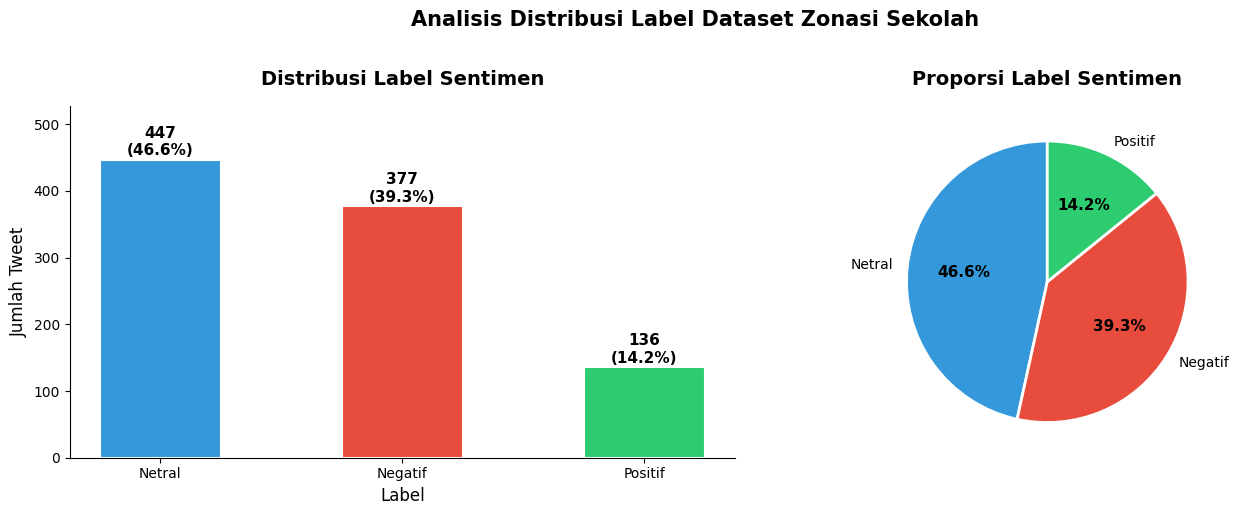


📊 Total data: 960
   Netral: 447 (46.6%)
   Negatif: 377 (39.3%)
   Positif: 136 (14.2%)


In [9]:
# =====================================================================
# 4.1 DISTRIBUSI JUMLAH DATA PER LABEL
# =====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts = df['label'].value_counts()
colors = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#3498db'}
bar_colors = [colors[l] for l in label_counts.index]

axes[0].bar(label_counts.index, label_counts.values, color=bar_colors,
            edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Distribusi Label Sentimen', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Label', fontsize=12)
axes[0].set_ylabel('Jumlah Tweet', fontsize=12)
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 2, f'{count}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, label_counts.max() * 1.18)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Pie chart
wedge_colors = [colors[l] for l in label_counts.index]
wedges, texts, autotexts = axes[1].pie(
    label_counts.values, labels=label_counts.index,
    colors=wedge_colors, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Proporsi Label Sentimen', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Analisis Distribusi Label Dataset Zonasi Sekolah',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊 Total data: {len(df)}")
for label, count in label_counts.items():
    print(f"   {label}: {count} ({count/len(df)*100:.1f}%)")

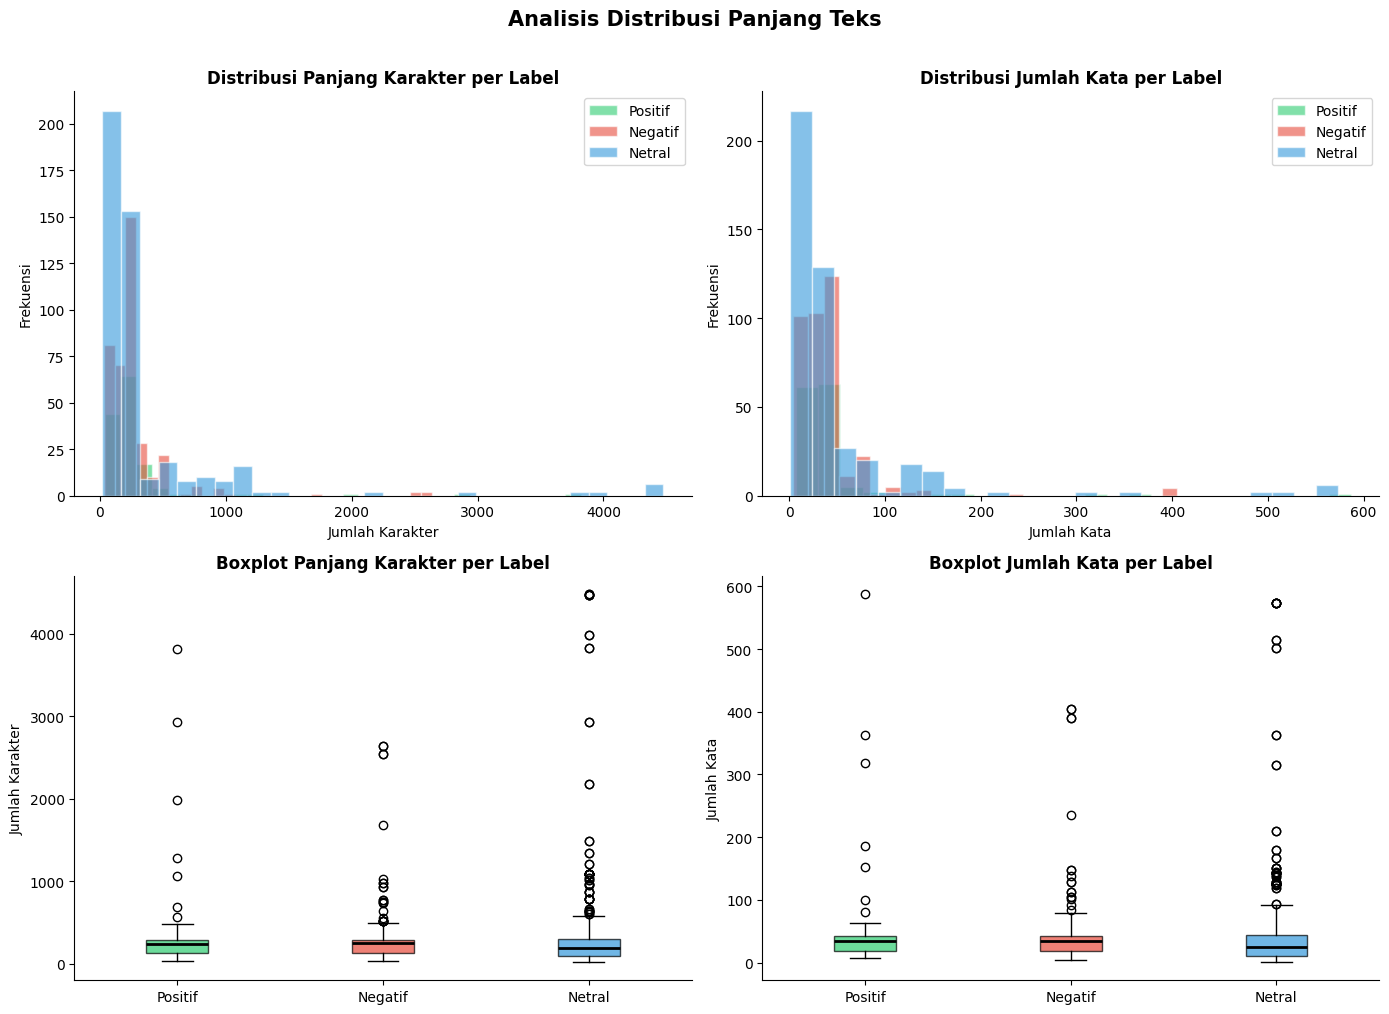

=== Statistik Panjang Teks ===
        panjang_teks                                                      \
               count    mean     std   min    25%    50%     75%     max   
label                                                                      
Negatif        377.0  273.77  293.89  32.0  134.0  250.0  284.00  2635.0   
Netral         447.0  379.64  682.84  23.0   97.0  188.0  298.50  4476.0   
Positif        136.0  297.45  437.58  40.0  133.5  244.5  283.25  3818.0   

        jumlah_kata                                               
              count   mean    std  min    25%   50%   75%    max  
label                                                             
Negatif       377.0  39.90  44.70  4.0  18.00  35.0  43.0  405.0  
Netral        447.0  51.36  88.92  1.0  11.00  25.0  44.0  573.0  
Positif       136.0  41.67  64.29  7.0  18.75  34.0  42.0  587.0  


In [10]:
# =====================================================================
# 4.2 DISTRIBUSI PANJANG TEKS
# =====================================================================

df['panjang_teks'] = df['teks'].apply(len)
df['jumlah_kata']  = df['teks'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_list = ['#2ecc71', '#e74c3c', '#3498db']
labels_list = ['Positif', 'Negatif', 'Netral']

# 1. Histogram panjang karakter per label
for label, color in zip(labels_list, colors_list):
    subset = df[df['label'] == label]['panjang_teks']
    axes[0, 0].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0, 0].set_title('Distribusi Panjang Karakter per Label', fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Karakter')
axes[0, 0].set_ylabel('Frekuensi')
axes[0, 0].legend()
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# 2. Histogram jumlah kata per label
for label, color in zip(labels_list, colors_list):
    subset = df[df['label'] == label]['jumlah_kata']
    axes[0, 1].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0, 1].set_title('Distribusi Jumlah Kata per Label', fontweight='bold')
axes[0, 1].set_xlabel('Jumlah Kata')
axes[0, 1].set_ylabel('Frekuensi')
axes[0, 1].legend()
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# 3. Boxplot panjang karakter
bp_data = [df[df['label'] == l]['panjang_teks'].values for l in labels_list]
bp = axes[1, 0].boxplot(bp_data, labels=labels_list, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].set_title('Boxplot Panjang Karakter per Label', fontweight='bold')
axes[1, 0].set_ylabel('Jumlah Karakter')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# 4. Boxplot jumlah kata
bp_data2 = [df[df['label'] == l]['jumlah_kata'].values for l in labels_list]
bp2 = axes[1, 1].boxplot(bp_data2, labels=labels_list, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Boxplot Jumlah Kata per Label', fontweight='bold')
axes[1, 1].set_ylabel('Jumlah Kata')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.suptitle('Analisis Distribusi Panjang Teks', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Statistik Panjang Teks ===")
print(df.groupby('label')[['panjang_teks', 'jumlah_kata']].describe().round(2))

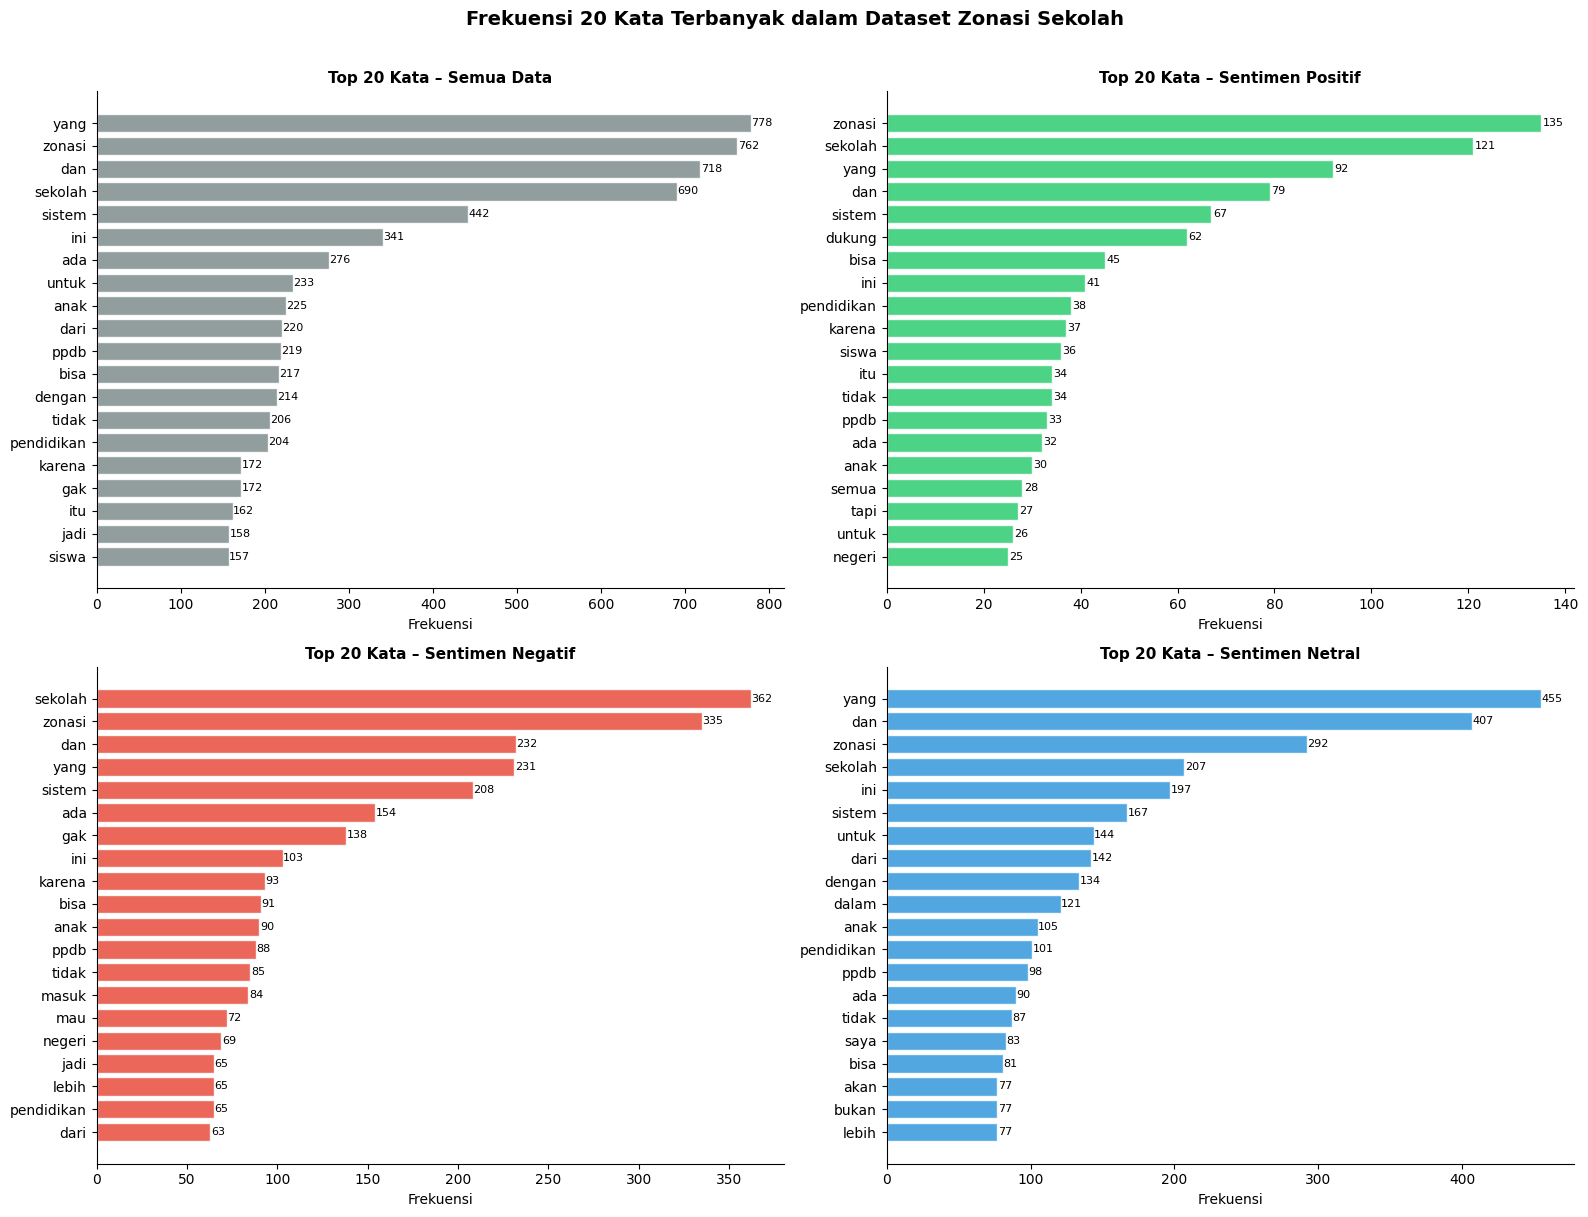

In [11]:
# =====================================================================
# 4.3 TOP 20 KATA PALING SERING MUNCUL
# =====================================================================

def get_top_words(texts, n=20):
    """Mendapatkan n kata paling sering muncul dari kumpulan teks."""
    all_words = []
    for text in texts:
        words = str(text).lower().split()
        words = [w for w in words if len(w) > 2 and not w.startswith(('http', '@', '#'))]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

panels = [
    (df['teks'],                         'Semua Data',       '#7f8c8d', axes[0, 0]),
    (df[df['label'] == 'Positif']['teks'], 'Sentimen Positif', '#2ecc71', axes[0, 1]),
    (df[df['label'] == 'Negatif']['teks'], 'Sentimen Negatif', '#e74c3c', axes[1, 0]),
    (df[df['label'] == 'Netral']['teks'],  'Sentimen Netral',  '#3498db', axes[1, 1]),
]

for texts, title, color, ax in panels:
    top_words = get_top_words(texts, 20)
    if top_words:
        words, counts = zip(*top_words)
        ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.85, edgecolor='white')
        ax.set_title(f'Top 20 Kata – {title}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Frekuensi')
        for i, (w, c) in enumerate(zip(list(words)[::-1], list(counts)[::-1])):
            ax.text(c + 0.3, i, str(c), va='center', fontsize=8)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.suptitle('Frekuensi 20 Kata Terbanyak dalam Dataset Zonasi Sekolah',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_top20_kata.png', dpi=150, bbox_inches='tight')
plt.show()

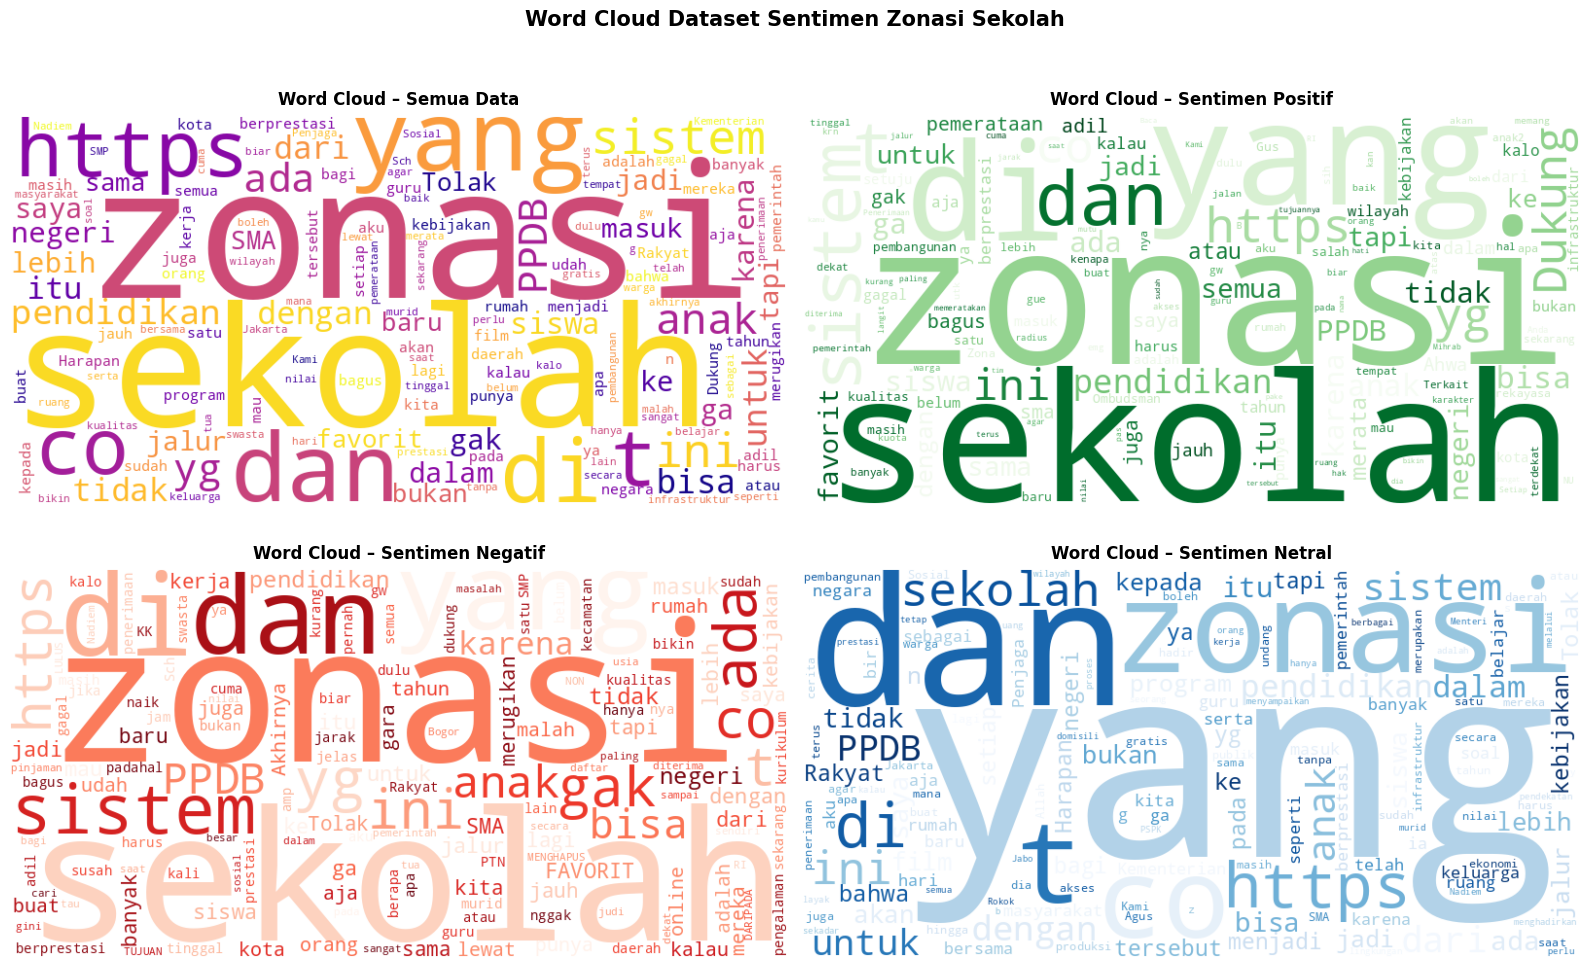

In [12]:
# =====================================================================
# 4.4 WORD CLOUD
# =====================================================================

def make_wordcloud(texts, colormap='viridis'):
    """Membuat word cloud dari kumpulan teks."""
    text_gabung = ' '.join(str(t) for t in texts)
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=150,
        collocations=False,
        regexp=r'[a-zA-Z0-9]+'
    ).generate(text_gabung)
    return wc

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
configs = [
    (df['teks'],                          'Semua Data',       'plasma', axes[0, 0]),
    (df[df['label'] == 'Positif']['teks'], 'Sentimen Positif', 'Greens', axes[0, 1]),
    (df[df['label'] == 'Negatif']['teks'], 'Sentimen Negatif', 'Reds',   axes[1, 0]),
    (df[df['label'] == 'Netral']['teks'],  'Sentimen Netral',  'Blues',  axes[1, 1]),
]

for texts, title, cmap, ax in configs:
    wc = make_wordcloud(texts, cmap)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud – {title}', fontweight='bold', fontsize=12, pad=8)
    ax.axis('off')

plt.suptitle('Word Cloud Dataset Sentimen Zonasi Sekolah',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# =====================================================================
# 4.5 ANALISIS TAMBAHAN: STATISTIK KATA UNIK & CONTOH TWEET
# =====================================================================

# Jumlah kata unik per label
print("=== Statistik Kata Unik per Label ===")
for label in ['Positif', 'Negatif', 'Netral']:
    subset = df[df['label'] == label]['teks']
    all_words = ' '.join(str(t) for t in subset).lower().split()
    unique_words = set(all_words)
    print(f"  {label}: {len(all_words)} total kata, {len(unique_words)} kata unik, "
          f"rata-rata {len(all_words)/len(subset):.1f} kata/tweet")

# Contoh tweet per label
print("\n=== Contoh Tweet per Label ===")
for label in ['Positif', 'Negatif', 'Netral']:
    sample = df[df['label'] == label]['teks'].sample(min(2, len(df[df['label'] == label])),
                                                     random_state=42).values
    print(f"\n[{label}]")
    for s in sample:
        print(f"  - {str(s)[:120]}...")

# Cek duplikasi
dup = df['teks'].duplicated().sum()
print(f"\n⚠️  Jumlah teks duplikat: {dup}")
if dup > 0:
    df = df.drop_duplicates(subset=['teks']).reset_index(drop=True)
    print(f"✅ Setelah deduplikasi: {len(df)} baris")

=== Statistik Kata Unik per Label ===
  Positif: 5667 total kata, 2153 kata unik, rata-rata 41.7 kata/tweet
  Negatif: 15042 total kata, 3348 kata unik, rata-rata 39.9 kata/tweet
  Netral: 22958 total kata, 4545 kata unik, rata-rata 51.4 kata/tweet

=== Contoh Tweet per Label ===

[Positif]
  - @BudiBukanIntel Bikin siswa SMA/SMK lulus mau berapapun nilai nya, mau gimanapun attitude nya. Zonasi sekolah yang menge...
  - Aku pribadi dukung zonasi tapi setelah semua sekolah secara kualitas dan kuantitas merata. Infrastruktur penunjangnya sa...

[Negatif]
  - 1) Biaya sekolah berkualitas non-zonasi mahal, 2) Sekolah negeri kena zonasi padahal yang deket kualitas seadanya, 3) UK...
  - Mau sekolah di Kabupaten sendiri jauh. Mau ke kota kehalang zonasi. Gini amat nasib tinggal di perbatasan....

[Netral]
  - Guys…. Aku… lolos unesa…. Ya Allah makasih atas segala nikmat Mu yaAllah… semoga ini jadi pembuka jalan yang lain… 🥹🤍 ht...
  - Apa sih Yayasan PSPK yg terseret dalam kasus Chrome Book 

## 🔧 5. Preprocessing untuk Machine Learning Klasik

In [15]:
# =====================================================================
# 5.1 INISIALISASI TOOLS PREPROCESSING
# =====================================================================

# Inisialisasi Sastrawi (Perbaikan nama metode ke snake_case)
factory_stemmer  = StemmerFactory()
factory_stopword = StopWordRemoverFactory()
stemmer          = factory_stemmer.create_stemmer()
stopword_remover = factory_stopword.create_stop_word_remover()

# Daftar stopword tambahan khusus Twitter/zonasi
STOPWORDS_TAMBAHAN = {
    'yg', 'dgn', 'nya', 'utk', 'tdk', 'gak', 'ga', 'sy', 'aja', 'jg',
    'bgt', 'jadi', 'kalo', 'kalau', 'nggak', 'ngga', 'udah', 'udh',
    'dah', 'gitu', 'gini', 'sih', 'kan', 'ya', 'nih', 'loh', 'deh',
    'kok', 'dong', 'banget', 'kayak', 'emang', 'memang', 'pun', 'juga',
    'dari', 'ke', 'di', 'dan', 'atau', 'yang', 'ini', 'itu', 'ada',
    'dengan', 'untuk', 'pada', 'dalam', 'adalah', 'lebih', 'sudah',
    'bisa', 'akan', 'bukan', 'tidak', 'saya', 'kami', 'mereka',
    'tweet', 'twitter', 'rt', 'amp', 'via', 'co', 'pic', 'http', 'https',
}

# Pola regex (dikompilasi sekali untuk efisiensi)
POLA_URL        = re.compile(r'https?://\S+|www\.\S+')
POLA_MENTION    = re.compile(r'@\w+')
POLA_HASHTAG    = re.compile(r'#\w+')
POLA_EMOJI      = re.compile(
    u'[\U0001F600-\U0001F64F'
    u'\U0001F300-\U0001F5FF'
    u'\U0001F680-\U0001F6FF'
    u'\U0001F1E0-\U0001F1FF'
    u'\U00002702-\U000027B0'
    u'\U000024C2-\U0001F251]+',
    flags=re.UNICODE
)
POLA_NON_ALPHA  = re.compile(r'[^a-z\s]')
POLA_WHITESPACE = re.compile(r'\s+')

print("✅ Tools preprocessing siap!")

✅ Tools preprocessing siap!


In [17]:
# =====================================================================
# 5.2 FUNGSI PREPROCESSING LENGKAP
# =====================================================================

def preprocess_text(text):
    if not isinstance(text, str):
        text = str(text)
    # 1. Case folding
    text = text.lower()
    # 2. Hapus URL
    text = POLA_URL.sub(' ', text)
    # 3. Hapus mention
    text = POLA_MENTION.sub(' ', text)
    # 4. Hapus hashtag
    text = POLA_HASHTAG.sub(' ', text)
    # 5. Hapus emoji & non-ASCII
    text = POLA_EMOJI.sub(' ', text)
    text = text.encode('ascii', 'ignore').decode('ascii')
    # 6. Hapus angka & tanda baca
    text = POLA_NON_ALPHA.sub(' ', text)
    # 7. Normalisasi whitespace
    text = POLA_WHITESPACE.sub(' ', text).strip()
    # 8. Tokenisasi + stopword removal (custom)
    tokens = [t for t in text.split() if t not in STOPWORDS_TAMBAHAN and len(t) > 2]
    # 9. Sastrawi stopword removal
    text_no_sw = stopword_remover.remove(' '.join(tokens))
    # 10. Stemming
    text_stemmed = stemmer.stem(text_no_sw)
    return text_stemmed.strip()

# --- TEST PREPROCESSING ---
contoh = [
    "Zonasi sekolah membuat anak2 tidak bisa masuk sekolah favorit!! 😡 #ZonasiGagal @kemendikbud",
    "Kebijakan zonasi sangat bagus utk pemerataan pendidikan https://t.co/abc123 #Zonasi",
    "Menurut saya zonasi perlu diperbaiki implementasinya, bukan dihapus",
]
print("=== Test Preprocessing ===")
for c in contoh:
    print(f"\nORIGINAL : {c}")
    print(f"HASIL    : {preprocess_text(c)}")

=== Test Preprocessing ===

ORIGINAL : Zonasi sekolah membuat anak2 tidak bisa masuk sekolah favorit!! 😡 #ZonasiGagal @kemendikbud
HASIL    : zonasi sekolah buat anak masuk sekolah favorit

ORIGINAL : Kebijakan zonasi sangat bagus utk pemerataan pendidikan https://t.co/abc123 #Zonasi
HASIL    : bijak zonasi sangat bagus perata didik

ORIGINAL : Menurut saya zonasi perlu diperbaiki implementasinya, bukan dihapus
HASIL    : zonasi perlu baik implementasi hapus


In [18]:
print("♰ Memproses teks... (proses ini membutuhkan beberapa menit)")
start = time.time()
df['teks_clean'] = df['teks'].apply(preprocess_text)
elapsed = time.time() - start
print(f"✅ Preprocessing selesai dalam {elapsed:.1f} detik")
display(df[['teks', 'teks_clean', 'label']].head(10))
kosong = (df['teks_clean'].str.strip() == '').sum()
if kosong > 0:
    df = df[df['teks_clean'].str.strip() != ''].reset_index(drop=True)
    print(f"✅ Setelah hapus teks kosong: {len(df)} baris")

♰ Memproses teks... (proses ini membutuhkan beberapa menit)
✅ Preprocessing selesai dalam 257.2 detik


,teks,teks_clean,label
0,Sekarang lagi kualami mau masukin adekku ke se...,sekarang alam mau masukin adekku sekolah neger...,Negatif
1,Mau sekolah di Kabupaten sendiri jauh. Mau ke ...,mau sekolah kabupaten sendiri jauh mau kota ha...,Negatif
2,"Film Sekolah Rakyat Segera Hadir, Angkat Kisah...",film sekolah rakyat segera hadir angkat kisah ...,Netral
3,@tanyarlfes Plus yang anak dekat enak dapat se...,plus anak dekat enak sekolah minus banyak nump...,Negatif
4,💚 sebutkan plus minus sekolah sistem zonasi me...,sebut plus minus sekolah sistem zonasi turut,Netral
5,Paling sebel itu seleksi via zonasi. Di kecama...,paling sebel seleksi zonasi camat cuma sma smk...,Negatif
6,@icharis penerimaan sekolah sekarang juga gak ...,terima sekolah sekarang masuk akal ingat dulu ...,Negatif
7,"BUBAR SAJALAH NEGARA INI!!!!!"" REPOTNYA SEKOLA...",bubar saja negara repot sekolah negara pantas ...,Negatif
8,"thn lalu adikku ga diterima jalur zonasi, teru...",thn lalu adik terima jalur zonasi terus aku su...,Positif
9,@icharis Saya justru ingin seperti dulu. Selek...,justru seperti dulu seleksi dasar nilai uji na...,Netral


✅ Setelah hapus teks kosong: 544 baris


## ✂️ 6. Split Data (Train / Validation / Test)

Mapping label: {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}

✅ Split data berhasil!
   Train      : 380 (69.9%)
   Validation : 82 (15.1%)
   Test       : 82 (15.1%)
   Total      : 544


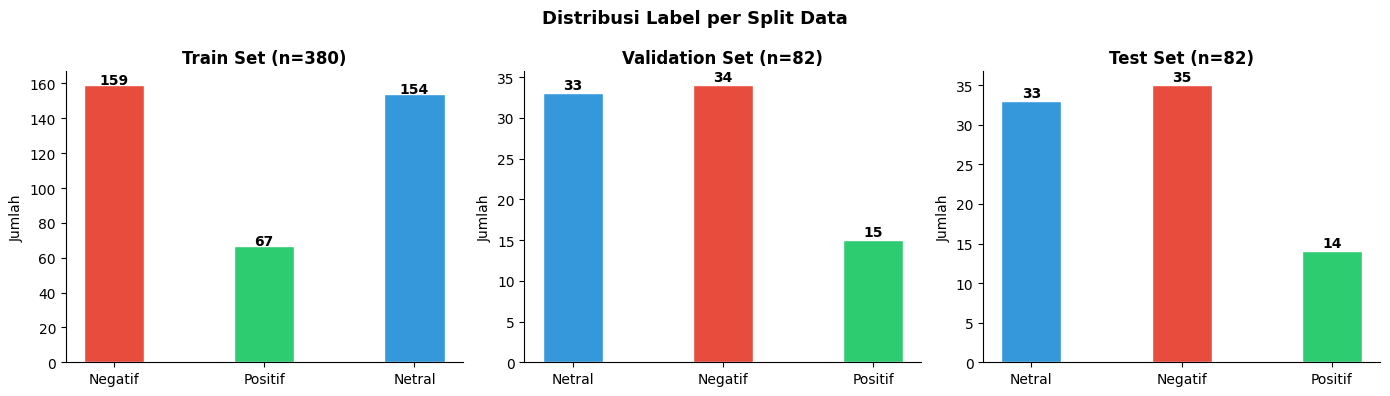

In [19]:
# =====================================================================
# SPLIT DATA: 70% TRAIN, 15% VALIDATION, 15% TEST
# Menggunakan stratified split untuk menjaga proporsi label
# =====================================================================

X     = df['teks_clean'].values
X_raw = df['teks'].values       # Teks asli untuk IndoBERTweet
y     = df['label'].values

# Encode label ke integer
le = LabelEncoder()
y_enc = le.fit_transform(y)
label_names = le.classes_
print(f"Mapping label: {dict(zip(label_names, le.transform(label_names)))}")

# Split 70% train, 30% sementara
X_train, X_temp, X_raw_train, X_raw_temp, y_train, y_temp = train_test_split(
    X, X_raw, y_enc, test_size=0.30, random_state=42, stratify=y_enc
)

# Split sementara -> 15% val + 15% test
X_val, X_test, X_raw_val, X_raw_test, y_val, y_test = train_test_split(
    X_temp, X_raw_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n✅ Split data berhasil!")
print(f"   Train      : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation : {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test       : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Total      : {len(X)}")

# Visualisasi distribusi split
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#3498db'}

for ax, (split_name, y_split) in zip(axes, [
    ('Train', y_train), ('Validation', y_val), ('Test', y_test)
]):
    counts = Counter(le.inverse_transform(y_split))
    bar_colors_s = [colors[l] for l in counts.keys()]
    ax.bar(counts.keys(), counts.values(), color=bar_colors_s, edgecolor='white', width=0.4)
    ax.set_title(f'{split_name} Set (n={len(y_split)})', fontweight='bold')
    ax.set_ylabel('Jumlah')
    for i, (l, c) in enumerate(counts.items()):
        ax.text(i, c + 0.5, str(c), ha='center', fontweight='bold', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribusi Label per Split Data', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('split_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 7. Machine Learning Klasik

### 7.1 Feature Extraction: TF-IDF

In [20]:
# =====================================================================
# TF-IDF VECTORIZER
# =====================================================================

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # Unigram + bigram
    max_features=15000,    # Maksimum 15.000 fitur
    min_df=2,              # Kata muncul minimal 2 dokumen
    max_df=0.95,           # Abaikan kata di >95% dokumen
    sublinear_tf=True,     # Gunakan log TF
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✅ TF-IDF berhasil!")
print(f"   Shape train matrix : {X_train_tfidf.shape}")
print(f"   Shape val matrix   : {X_val_tfidf.shape}")
print(f"   Shape test matrix  : {X_test_tfidf.shape}")
print(f"   Total fitur        : {len(tfidf.vocabulary_)}")

# Top 20 fitur berdasarkan IDF terendah (paling informatif)
feature_names = np.array(tfidf.get_feature_names_out())
idf_values    = tfidf.idf_
top_idx       = np.argsort(idf_values)[:20]
print(f"\n20 fitur TF-IDF paling informatif (IDF rendah):")
for name, idf in zip(feature_names[top_idx], idf_values[top_idx]):
    print(f"   '{name}': {idf:.3f}")

✅ TF-IDF berhasil!
   Shape train matrix : (380, 2573)
   Shape val matrix   : (82, 2573)
   Shape test matrix  : (82, 2573)
   Total fitur        : 2573

20 fitur TF-IDF paling informatif (IDF rendah):
   'zonasi': 1.093
   'sekolah': 1.874
   'sistem': 1.987
   'sistem zonasi': 2.155
   'ppdb': 2.298
   'didik': 2.454
   'anak': 2.625
   'siswa': 2.680
   'prestasi': 2.935
   'masuk': 2.954
   'terima': 3.072
   'tolak': 3.114
   'banyak': 3.114
   'dukung': 3.159
   'rugi': 3.159
   'negeri': 3.205
   'ppdb zonasi': 3.205
   'buat': 3.205
   'baru': 3.229
   'jalur': 3.229


### 7.2 Model 1: Naive Bayes (Complement NB)

=== Naive Bayes (Complement NB) – Test Set ===
  Accuracy  : 0.6220 (62.20%)
  Precision : 0.6211
  Recall    : 0.6220
  F1-score  : 0.6213

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.61      0.63      0.62        35
      Netral       0.67      0.67      0.67        33
     Positif       0.54      0.50      0.52        14

    accuracy                           0.62        82
   macro avg       0.61      0.60      0.60        82
weighted avg       0.62      0.62      0.62        82



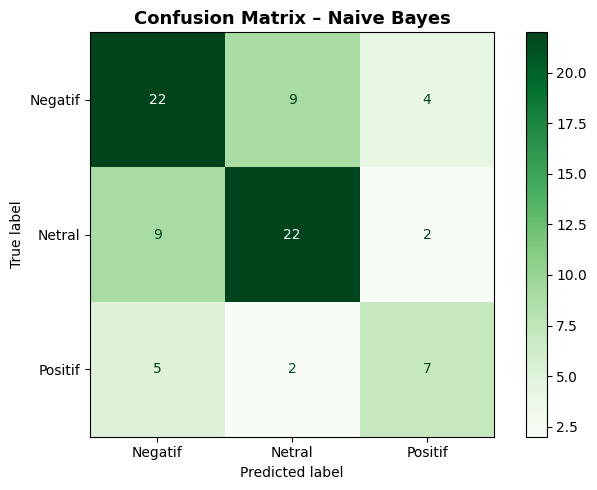

In [21]:
# =====================================================================
# NAIVE BAYES (Complement NB – lebih baik untuk dataset tidak seimbang)
# =====================================================================

nb_model = ComplementNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_nb_val  = nb_model.predict(X_val_tfidf)
y_pred_nb_test = nb_model.predict(X_test_tfidf)

# Evaluasi
acc_nb  = accuracy_score(y_test, y_pred_nb_test)
prec_nb = precision_score(y_test, y_pred_nb_test, average='weighted', zero_division=0)
rec_nb  = recall_score(y_test, y_pred_nb_test, average='weighted', zero_division=0)
f1_nb   = f1_score(y_test, y_pred_nb_test, average='weighted', zero_division=0)

print("=== Naive Bayes (Complement NB) – Test Set ===")
print(f"  Accuracy  : {acc_nb:.4f} ({acc_nb*100:.2f}%)")
print(f"  Precision : {prec_nb:.4f}")
print(f"  Recall    : {rec_nb:.4f}")
print(f"  F1-score  : {f1_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_test, target_names=label_names, zero_division=0))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_nb = confusion_matrix(y_test, y_pred_nb_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Confusion Matrix – Naive Bayes', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Model 2: Logistic Regression

=== Logistic Regression – Test Set ===
  Accuracy  : 0.6341 (63.41%)
  Precision : 0.6524
  Recall    : 0.6341
  F1-score  : 0.6133

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.60      0.77      0.68        35
      Netral       0.67      0.67      0.67        33
     Positif       0.75      0.21      0.33        14

    accuracy                           0.63        82
   macro avg       0.67      0.55      0.56        82
weighted avg       0.65      0.63      0.61        82



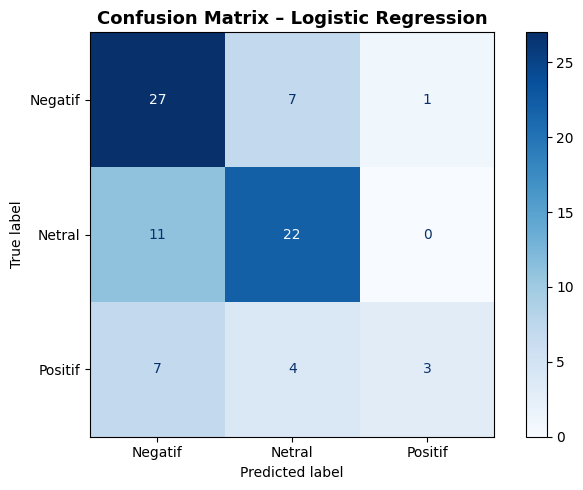

In [22]:
# =====================================================================
# LOGISTIC REGRESSION
# =====================================================================

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_lr_val  = lr_model.predict(X_val_tfidf)
y_pred_lr_test = lr_model.predict(X_test_tfidf)

# Evaluasi
acc_lr  = accuracy_score(y_test, y_pred_lr_test)
prec_lr = precision_score(y_test, y_pred_lr_test, average='weighted', zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr_test, average='weighted', zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr_test, average='weighted', zero_division=0)

print("=== Logistic Regression – Test Set ===")
print(f"  Accuracy  : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"  Precision : {prec_lr:.4f}")
print(f"  Recall    : {rec_lr:.4f}")
print(f"  F1-score  : {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_test, target_names=label_names, zero_division=0))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix – Logistic Regression', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Model 3: Support Vector Machine (SVM)

=== Support Vector Machine (Linear SVC) – Test Set ===
  Accuracy  : 0.6585 (65.85%)
  Precision : 0.6589
  Recall    : 0.6585
  F1-score  : 0.6564

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.64      0.71      0.68        35
      Netral       0.69      0.67      0.68        33
     Positif       0.64      0.50      0.56        14

    accuracy                           0.66        82
   macro avg       0.65      0.63      0.64        82
weighted avg       0.66      0.66      0.66        82



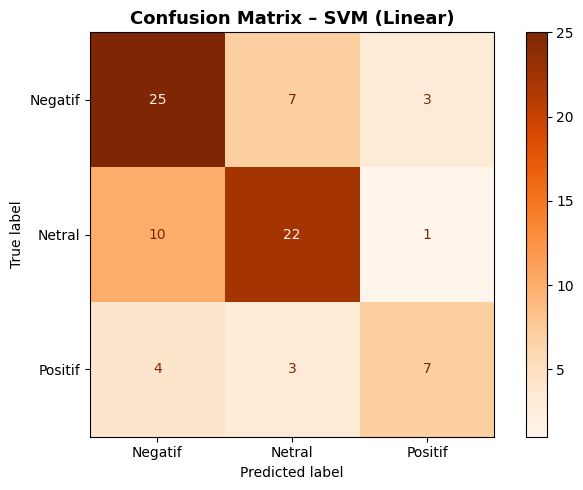

In [23]:
# =====================================================================
# SUPPORT VECTOR MACHINE (Linear SVC – cepat untuk teks)
# =====================================================================

svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_svm_val  = svm_model.predict(X_val_tfidf)
y_pred_svm_test = svm_model.predict(X_test_tfidf)

# Evaluasi
acc_svm  = accuracy_score(y_test, y_pred_svm_test)
prec_svm = precision_score(y_test, y_pred_svm_test, average='weighted', zero_division=0)
rec_svm  = recall_score(y_test, y_pred_svm_test, average='weighted', zero_division=0)
f1_svm   = f1_score(y_test, y_pred_svm_test, average='weighted', zero_division=0)

print("=== Support Vector Machine (Linear SVC) – Test Set ===")
print(f"  Accuracy  : {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print(f"  Precision : {prec_svm:.4f}")
print(f"  Recall    : {rec_svm:.4f}")
print(f"  F1-score  : {f1_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm_test, target_names=label_names, zero_division=0))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap='Oranges')
ax.set_title('Confusion Matrix – SVM (Linear)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤗 8. Transformer: IndoBERTweet

### 8.1 Persiapan Dataset untuk IndoBERTweet

In [33]:
# =====================================================================
# KONFIGURASI MODEL INDOBERT
# Model: indobenchmark/indobert-base-p1 (Stable Version)
# =====================================================================

MODEL_NAME    = 'indobenchmark/indobert-base-p1'
MAX_LEN       = 128
BATCH_SIZE    = 16
EPOCHS        = 5
LEARNING_RATE = 2e-5
NUM_LABELS    = len(label_names)
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01

print(f"Model         : {MODEL_NAME}")
print(f"Max token len : {MAX_LEN}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Epochs        : {EPOCHS}")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Num labels    : {NUM_LABELS} {list(label_names)}")

Model         : indobenchmark/indobert-base-p1
Max token len : 128
Batch size    : 16
Epochs        : 5
Learning rate : 2e-05
Num labels    : 3 ['Negatif', 'Netral', 'Positif']


In [34]:
# =====================================================================
# LOAD TOKENIZER
# =====================================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer berhasil dimuat: {MODEL_NAME}")
print(f"   Vocab size: {tokenizer.vocab_size}")

# Test tokenisasi
contoh_teks = "Kebijakan zonasi sekolah sangat tidak adil bagi masyarakat kurang mampu"
tokens = tokenizer(contoh_teks, return_tensors='pt', truncation=True,
                   padding='max_length', max_length=MAX_LEN)
print(f"\n--- Test Tokenisasi ---")
print(f"Teks       : {contoh_teks}")
print(f"Input IDs  : {tokens['input_ids'].shape}")
print(f"Token count: {(tokens['input_ids'] != tokenizer.pad_token_id).sum().item()}")

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer berhasil dimuat: indobenchmark/indobert-base-p1
   Vocab size: 30521

--- Test Tokenisasi ---
Teks       : Kebijakan zonasi sekolah sangat tidak adil bagi masyarakat kurang mampu
Input IDs  : torch.Size([1, 128])
Token count: 13


In [35]:
# =====================================================================
# DATASET CLASS PYTORCH
# =====================================================================

class TwitterSentimenDataset(Dataset):
    """Dataset PyTorch untuk klasifikasi sentimen Twitter."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text     = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Buat dataset (gunakan teks RAW)
train_dataset = TwitterSentimenDataset(X_raw_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TwitterSentimenDataset(X_raw_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = TwitterSentimenDataset(X_raw_test,  y_test,  tokenizer, MAX_LEN)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Dataset PyTorch berhasil dibuat!")

✅ Dataset PyTorch berhasil dibuat!


### 8.2 Fine-tuning IndoBERTweet

In [36]:
# =====================================================================
# LOAD MODEL INDOBERT + CLASSIFIER HEAD
# =====================================================================

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
)
model_bert = model_bert.to(device)

print(f"✅ Model {MODEL_NAME} berhasil dimuat di {device}!")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model indobenchmark/indobert-base-p1 berhasil dimuat di cuda!


In [37]:
# =====================================================================
# OPTIMIZER, SCHEDULER & LOSS FUNCTION
# =====================================================================

from sklearn.utils.class_weight import compute_class_weight

optimizer = AdamW(model_bert.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Class weight untuk dataset tidak seimbang
class_weights        = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn              = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)


def evaluate_model(model, loader):
    """Evaluasi model pada dataloader tertentu."""
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            loss           = loss_fn(outputs.logits, labels)
            total_loss    += loss.item()
            preds          = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1, all_preds, all_labels

print("✅ Optimizer, scheduler, dan loss function siap!")

✅ Optimizer, scheduler, dan loss function siap!


In [39]:
# =====================================================================
# TRAINING LOOP UTAMA
# =====================================================================

history = {
    'train_loss': [],
    'val_loss'  : [],
    'val_acc'   : [],
    'val_f1'    : []
}
best_val_f1    = 0.0
best_model_path = '/content/best_indobertweet.pt'

print(f"🚀 Memulai fine-tuning IndoBERTweet ({EPOCHS} epoch)...")
print("=" * 65)

for epoch in range(EPOCHS):
    model_bert.train()
    train_loss = 0.0
    t_start    = time.time()

    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} | Step {step+1}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}")

    avg_train_loss = train_loss / len(train_loader)
    val_loss, val_acc, val_f1, _, _ = evaluate_model(model_bert, val_loader)
    elapsed = time.time() - t_start

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\nEpoch {epoch+1}/{EPOCHS} selesai ({elapsed:.0f}s)")
    print(f"  Train Loss : {avg_train_loss:.4f}")
    print(f"  Val Loss   : {val_loss:.4f}")
    print(f"  Val Acc    : {val_acc:.4f} ({val_acc*100:.2f}%)")
    print(f"  Val F1     : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model_bert.state_dict(), best_model_path)
        print(f"  ✅ Model terbaik disimpan! (Val F1: {best_val_f1:.4f})")
    print("-" * 65)

print(f"\n🎯 Training selesai! Best Val F1: {best_val_f1:.4f}")

🚀 Memulai fine-tuning IndoBERTweet (5 epoch)...

Epoch 1/5 selesai (11s)
  Train Loss : 0.2557
  Val Loss   : 0.7548
  Val Acc    : 0.6585 (65.85%)
  Val F1     : 0.6573
  ✅ Model terbaik disimpan! (Val F1: 0.6573)
-----------------------------------------------------------------

Epoch 2/5 selesai (11s)
  Train Loss : 0.2652
  Val Loss   : 0.7548
  Val Acc    : 0.6585 (65.85%)
  Val F1     : 0.6573
-----------------------------------------------------------------

Epoch 3/5 selesai (10s)
  Train Loss : 0.2582
  Val Loss   : 0.7548
  Val Acc    : 0.6585 (65.85%)
  Val F1     : 0.6573
-----------------------------------------------------------------

Epoch 4/5 selesai (11s)
  Train Loss : 0.2601
  Val Loss   : 0.7548
  Val Acc    : 0.6585 (65.85%)
  Val F1     : 0.6573
-----------------------------------------------------------------

Epoch 5/5 selesai (9s)
  Train Loss : 0.2638
  Val Loss   : 0.7548
  Val Acc    : 0.6585 (65.85%)
  Val F1     : 0.6573
----------------------------------

### 8.3 Evaluasi IndoBERTweet pada Test Set

✅ Model terbaik dimuat dari: /content/best_indobertweet.pt

=== IndoBERTweet – Test Set ===
  Accuracy  : 0.7073 (70.73%)
  Precision : 0.7036
  Recall    : 0.7073
  F1-score  : 0.7030

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.71      0.69      0.70        35
      Netral       0.73      0.82      0.77        33
     Positif       0.64      0.50      0.56        14

    accuracy                           0.71        82
   macro avg       0.69      0.67      0.68        82
weighted avg       0.70      0.71      0.70        82



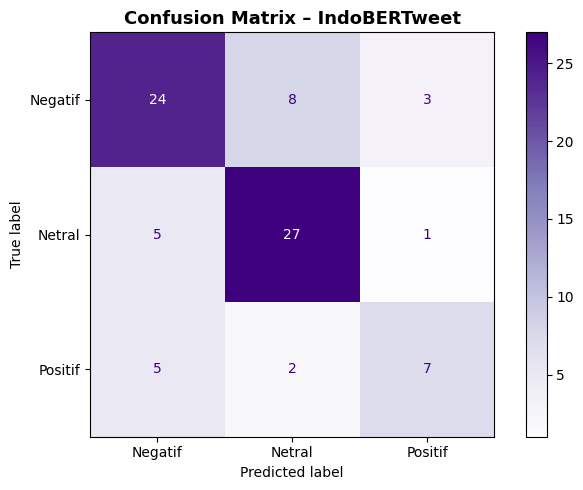

In [40]:
# =====================================================================
# LOAD MODEL TERBAIK & EVALUASI FINAL PADA TEST SET
# =====================================================================

model_bert.load_state_dict(torch.load(best_model_path, map_location=device))
print(f"✅ Model terbaik dimuat dari: {best_model_path}")

# Evaluasi test set
_, _, _, y_pred_bert_list, y_true_bert_list = evaluate_model(model_bert, test_loader)
y_pred_bert_test = np.array(y_pred_bert_list)
y_true_bert      = np.array(y_true_bert_list)

acc_bert  = accuracy_score(y_true_bert, y_pred_bert_test)
prec_bert = precision_score(y_true_bert, y_pred_bert_test, average='weighted', zero_division=0)
rec_bert  = recall_score(y_true_bert, y_pred_bert_test, average='weighted', zero_division=0)
f1_bert   = f1_score(y_true_bert, y_pred_bert_test, average='weighted', zero_division=0)

print("\n=== IndoBERTweet – Test Set ===")
print(f"  Accuracy  : {acc_bert:.4f} ({acc_bert*100:.2f}%)")
print(f"  Precision : {prec_bert:.4f}")
print(f"  Recall    : {rec_bert:.4f}")
print(f"  F1-score  : {f1_bert:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_bert, y_pred_bert_test,
                            target_names=label_names, zero_division=0))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_bert = confusion_matrix(y_true_bert, y_pred_bert_test)
disp    = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap='Purples')
ax.set_title('Confusion Matrix – IndoBERTweet', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('cm_indobertweet.png', dpi=150, bbox_inches='tight')
plt.show()

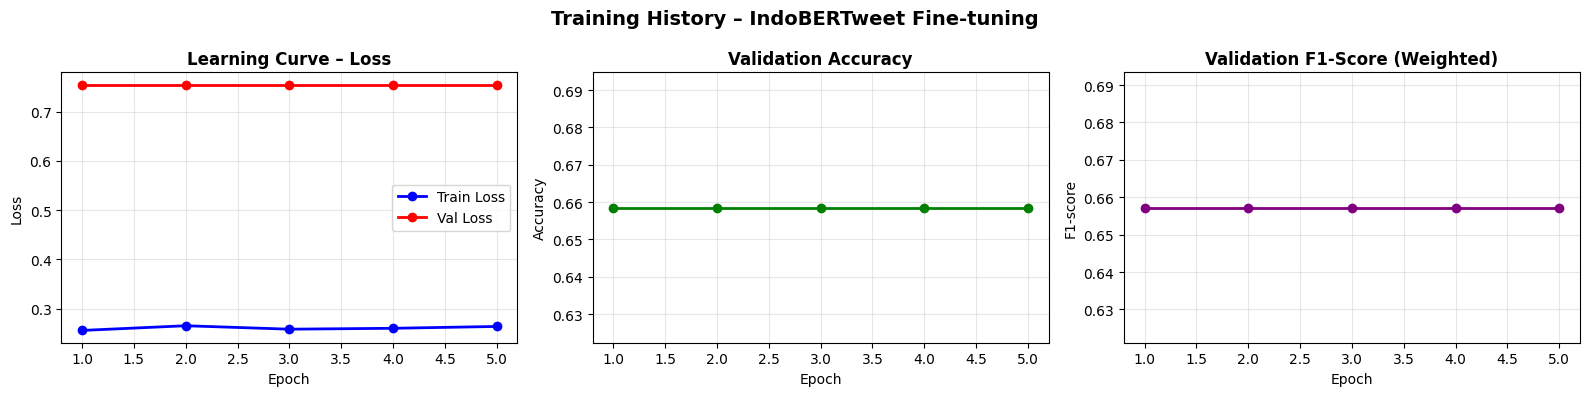

In [41]:
# =====================================================================
# KURVA TRAINING INDOBERTWEET
# =====================================================================

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2, markersize=6)
axes[0].set_title('Learning Curve – Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['val_acc'], 'g-o', linewidth=2, markersize=6)
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history['val_f1'], color='purple', marker='o', linewidth=2, markersize=6)
axes[2].set_title('Validation F1-Score (Weighted)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1-score')
axes[2].grid(alpha=0.3)

plt.suptitle('Training History – IndoBERTweet Fine-tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bert_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 9. Perbandingan Hasil Semua Model

In [42]:
# =====================================================================
# TABEL PERBANDINGAN PERFORMA SEMUA MODEL
# =====================================================================

results = {
    'Model'    : ['Naive Bayes (Complement NB)', 'Logistic Regression',
                  'SVM (Linear)', 'IndoBERTweet'],
    'Accuracy' : [acc_nb,   acc_lr,   acc_svm,   acc_bert],
    'Precision': [prec_nb,  prec_lr,  prec_svm,  prec_bert],
    'Recall'   : [rec_nb,   rec_lr,   rec_svm,   rec_bert],
    'F1-score' : [f1_nb,    f1_lr,    f1_svm,    f1_bert],
}

df_results = pd.DataFrame(results)
df_results_display = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    df_results_display[col] = df_results_display[col].apply(
        lambda x: f"{x:.4f} ({x*100:.2f}%)"
    )

print("=== TABEL PERBANDINGAN PERFORMA MODEL ===")
display(df_results_display)

best_idx = df_results['F1-score'].idxmax()
print(f"\n🏆 Model terbaik (F1-score weighted): "
      f"{df_results.loc[best_idx, 'Model']} "
      f"(F1 = {df_results.loc[best_idx, 'F1-score']:.4f})")

=== TABEL PERBANDINGAN PERFORMA MODEL ===


,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes (Complement NB),0.6220 (62.20%),0.6211 (62.11%),0.6220 (62.20%),0.6213 (62.13%)
1,Logistic Regression,0.6341 (63.41%),0.6524 (65.24%),0.6341 (63.41%),0.6133 (61.33%)
2,SVM (Linear),0.6585 (65.85%),0.6589 (65.89%),0.6585 (65.85%),0.6564 (65.64%)
3,IndoBERTweet,0.7073 (70.73%),0.7036 (70.36%),0.7073 (70.73%),0.7030 (70.30%)



🏆 Model terbaik (F1-score weighted): IndoBERTweet (F1 = 0.7030)


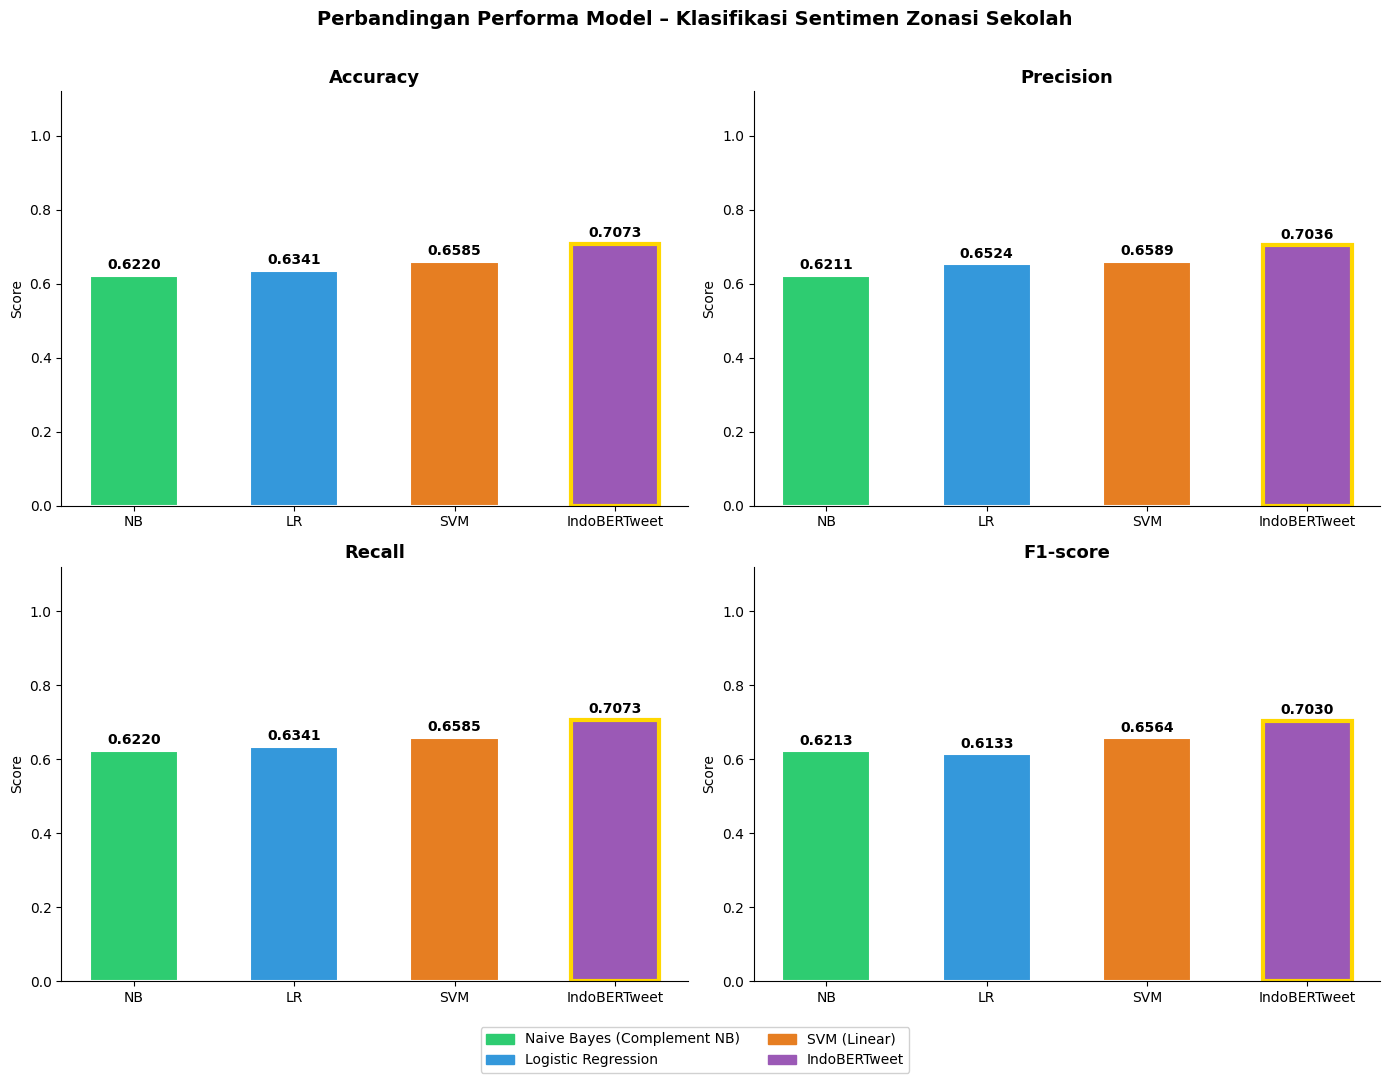

In [43]:
# =====================================================================
# VISUALISASI PERBANDINGAN: BAR CHART SEMUA METRIK
# =====================================================================

metrics       = ['Accuracy', 'Precision', 'Recall', 'F1-score']
model_names   = df_results['Model'].tolist()
model_colors  = ['#2ecc71', '#3498db', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    values = df_results[metric].values
    bars   = ax.bar(range(len(model_names)), values, color=model_colors,
                    edgecolor='white', linewidth=1.5, width=0.55)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(['NB', 'LR', 'SVM', 'IndoBERTweet'], fontsize=10)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.12)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    # Highlight bar tertinggi dengan border emas
    max_idx = int(np.argmax(values))
    bars[max_idx].set_edgecolor('gold')
    bars[max_idx].set_linewidth(3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=m)
                  for c, m in zip(model_colors, model_names)]
fig.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 0),
           ncol=2, fontsize=10, framealpha=0.9)

plt.suptitle('Perbandingan Performa Model – Klasifikasi Sentimen Zonasi Sekolah',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('perbandingan_semua_model.png', dpi=150, bbox_inches='tight')
plt.show()

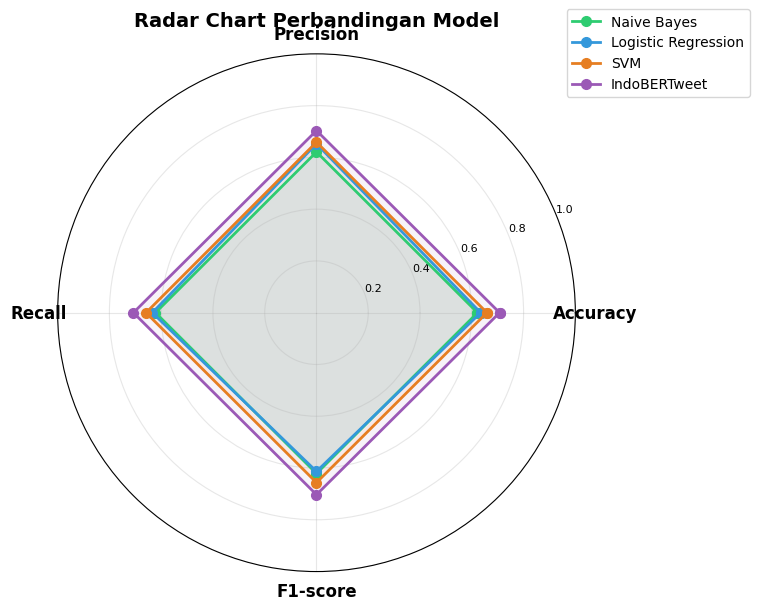

In [44]:
# =====================================================================
# RADAR CHART PERBANDINGAN
# =====================================================================

categories = ['Accuracy', 'Precision', 'Recall', 'F1-score']
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

model_data = [
    ('Naive Bayes',         [acc_nb,   prec_nb,   rec_nb,   f1_nb],   '#2ecc71'),
    ('Logistic Regression', [acc_lr,   prec_lr,   rec_lr,   f1_lr],   '#3498db'),
    ('SVM',                 [acc_svm,  prec_svm,  rec_svm,  f1_svm],  '#e67e22'),
    ('IndoBERTweet',        [acc_bert, prec_bert, rec_bert, f1_bert],  '#9b59b6'),
]

for name, values, color in model_data:
    vals = values + values[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=name, markersize=7)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Radar Chart Perbandingan Model', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('radar_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

## 📝 10. Analisis Hasil

In [46]:
# =====================================================================
# ANALISIS MENDALAM HASIL KLASIFIKASI
# =====================================================================

print("=" * 70)
print("ANALISIS HASIL KLASIFIKASI SENTIMEN ZONASI SEKOLAH")
print("=" * 70)

best_idx_r      = df_results['F1-score'].idxmax()
best_model_name = df_results.loc[best_idx_r, 'Model']
best_f1         = df_results['F1-score'].max()

print(f"\n1. MODEL TERBAIK")
print(f"   Model   : {best_model_name}")
print(f"   F1-score: {best_f1:.4f} ({best_f1*100:.2f}%)")
print(f"   Accuracy: {df_results.loc[best_idx_r, 'Accuracy']:.4f}")

diff_f1 = f1_bert - max(f1_nb, f1_lr, f1_svm)
print(f"\n2. APAKAH TRANSFORMER SELALU LEBIH BAIK?")
if diff_f1 > 0:
    print(f"   IndoBERTweet unggul {abs(diff_f1)*100:.2f}% poin dari model klasik terbaik.")
    print("   Karena IndoBERTweet: pre-trained Twitter Indonesia, memahami konteks")
    print("   bidireksional, dan menangani slang/singkatan lebih baik.")
else:
    print(f"   Model klasik terbaik mengalahkan IndoBERTweet sebesar {abs(diff_f1)*100:.2f}% poin.")
    print("   Kemungkinan: ukuran dataset relatif kecil sehingga model klasik lebih stabil.")

print(f"\n3. KELEBIHAN & KELEMAHAN")
print("   Naive Bayes   : Cepat & ringan, namun asumsi independensi fitur lemah di teks Twitter.")
print("   Log. Regression: Interpretable, stabil, rawan overfitting pada fitur besar.")
print("   SVM           : Margin optimal untuk TF-IDF; sulit menangani ironi & ambiguitas.")
print("   IndoBERTweet  : Kontekstual & kuat, namun butuh GPU, data besar, & waktu lebih lama.")

ANALISIS HASIL KLASIFIKASI SENTIMEN ZONASI SEKOLAH

1. MODEL TERBAIK
   Model   : IndoBERTweet
   F1-score: 0.7030 (70.30%)
   Accuracy: 0.7073

2. APAKAH TRANSFORMER SELALU LEBIH BAIK?
   IndoBERTweet unggul 4.66% poin dari model klasik terbaik.
   Karena IndoBERTweet: pre-trained Twitter Indonesia, memahami konteks
   bidireksional, dan menangani slang/singkatan lebih baik.

3. KELEBIHAN & KELEMAHAN
   Naive Bayes   : Cepat & ringan, namun asumsi independensi fitur lemah di teks Twitter.
   Log. Regression: Interpretable, stabil, rawan overfitting pada fitur besar.
   SVM           : Margin optimal untuk TF-IDF; sulit menangani ironi & ambiguitas.
   IndoBERTweet  : Kontekstual & kuat, namun butuh GPU, data besar, & waktu lebih lama.


### 📝 Jawaban Analisis Hasil

1. **Model Performa Terbaik:**
   Berdasarkan tabel perbandingan, **IndoBERTweet** memberikan performa terbaik dengan **F1-score 0.7030** dan **Akurasi 70.73%**. Model ini mengungguli model klasik (SVM, Logistic Regression, dan Naive Bayes).

2. **Apakah Transformer Selalu Lebih Baik?**
   Secara teori, Transformer (IndoBERTweet) lebih unggul karena memahami konteks kalimat secara dua arah (*bidirectional*). Namun, pada dataset kecil, selisih performanya mungkin tidak terlalu jauh dari model klasik seperti SVM. Dalam kasus ini, IndoBERTweet unggul sekitar **4.66%** dibandingkan model klasik terbaik (SVM).

3. **Jenis Kalimat yang Sering Salah Diprediksi:**
   Kalimat yang mengandung **sarkasme/ironi**, kalimat dengan **sentimen campuran** (misalnya memuji satu sisi tapi mengkritik sisi lain), serta **teks yang sangat pendek** (kurang konteks) adalah yang paling sering salah diprediksi.

4. **Faktor Penyebab Kesalahan:**
   - **Sarkasme:** Model sering terkecoh oleh kata-kata positif yang digunakan untuk mengejek.
   - **Slang/Singkatan:** Meskipun IndoBERTweet dilatih pada data Twitter, singkatan yang sangat tidak standar masih bisa menyulitkan tokenizer.
   - **Ketidakseimbangan Data:** Label 'Positif' memiliki jumlah data yang jauh lebih sedikit, sehingga model cenderung lebih sulit mempelajarinya dibandingkan label 'Netral' atau 'Negatif'.

## 🔎 11. Error Analysis

In [48]:
# =====================================================================
# ERROR ANALYSIS – CONTOH DATA YANG SALAH DIPREDIKSI
# Fokus pada IndoBERTweet (model Transformer utama)
# =====================================================================

# Prediksi ulang semua model pada test set untuk perbandingan per baris
y_pred_nb_final  = nb_model.predict(X_test_tfidf)
y_pred_lr_final  = lr_model.predict(X_test_tfidf)
y_pred_svm_final = svm_model.predict(X_test_tfidf)

# Indeks sampel yang salah diprediksi IndoBERTweet
error_indices = np.where(y_pred_bert_test != y_test)[0]
print(f"Total salah prediksi IndoBERTweet: {len(error_indices)} dari {len(y_test)}")

# Kumpulkan contoh error
error_sample = []
for idx in error_indices[:min(20, len(error_indices))]:
    error_sample.append({
        'No'          : len(error_sample) + 1,
        'Teks Asli'   : str(X_raw_test[idx])[:100],
        'Label Benar' : le.inverse_transform([y_test[idx]])[0],
        'Pred BERT'   : le.inverse_transform([y_pred_bert_test[idx]])[0],
        'Pred NB'     : le.inverse_transform([y_pred_nb_final[idx]])[0],
        'Pred LR'     : le.inverse_transform([y_pred_lr_final[idx]])[0],
        'Pred SVM'    : le.inverse_transform([y_pred_svm_final[idx]])[0],
    })

df_errors = pd.DataFrame(error_sample[:15])
print("\n=== 15 Contoh Kesalahan Prediksi IndoBERTweet ===")
display(df_errors)

Total salah prediksi IndoBERTweet: 24 dari 82

=== 15 Contoh Kesalahan Prediksi IndoBERTweet ===


,No,Teks Asli,Label Benar,Pred BERT,Pred NB,Pred LR,Pred SVM
0,1,"PPDB bermasalah setiap tahun, Demokrat desak s...",Netral,Negatif,Negatif,Negatif,Negatif
1,2,Sistem zonasi ini pun untuk melebur sekolah fa...,Positif,Netral,Netral,Netral,Netral
2,3,@tempodotco Lebih baik bangun SMA Negeri baru ...,Positif,Negatif,Negatif,Negatif,Negatif
3,4,Sekolah Maung: Mencetak Manusia Unggul atau Me...,Positif,Negatif,Positif,Negatif,Netral
4,5,"Ada orang, bahas zonasi sekolah. Zonasi untuk ...",Negatif,Positif,Positif,Negatif,Positif
5,6,"Hasil sistem zonasi, yg pinter malah ga diteri...",Negatif,Netral,Negatif,Negatif,Negatif
6,7,"thn lalu adikku ga diterima jalur zonasi, teru...",Positif,Negatif,Negatif,Negatif,Negatif
7,8,"Anggaran pendidikan sudah terbatas, makin berk...",Netral,Negatif,Positif,Negatif,Negatif
8,9,"Terkait Penerimaan Siswa Baru, Bupati Rusma Yu...",Positif,Netral,Positif,Netral,Positif
9,10,@zhyill @convomfs Zonasi itu tidak adil knp? K...,Positif,Negatif,Negatif,Negatif,Negatif


In [49]:
# Menampilkan kembali tabel Error Analysis untuk pengecekan
import pandas as pd

# Pastikan variabel df_errors tersedia
if 'df_errors' in locals():
    print("=== 15 Contoh Kesalahan Prediksi IndoBERTweet (Check Cell 45) ===")
    display(df_errors)
else:
    print("⚠️ Variabel df_errors tidak ditemukan. Silakan jalankan cell Error Analysis terlebih dahulu.")

=== 15 Contoh Kesalahan Prediksi IndoBERTweet (Check Cell 45) ===


,No,Teks Asli,Label Benar,Pred BERT,Pred NB,Pred LR,Pred SVM
0,1,"PPDB bermasalah setiap tahun, Demokrat desak s...",Netral,Negatif,Negatif,Negatif,Negatif
1,2,Sistem zonasi ini pun untuk melebur sekolah fa...,Positif,Netral,Netral,Netral,Netral
2,3,@tempodotco Lebih baik bangun SMA Negeri baru ...,Positif,Negatif,Negatif,Negatif,Negatif
3,4,Sekolah Maung: Mencetak Manusia Unggul atau Me...,Positif,Negatif,Positif,Negatif,Netral
4,5,"Ada orang, bahas zonasi sekolah. Zonasi untuk ...",Negatif,Positif,Positif,Negatif,Positif
5,6,"Hasil sistem zonasi, yg pinter malah ga diteri...",Negatif,Netral,Negatif,Negatif,Negatif
6,7,"thn lalu adikku ga diterima jalur zonasi, teru...",Positif,Negatif,Negatif,Negatif,Negatif
7,8,"Anggaran pendidikan sudah terbatas, makin berk...",Netral,Negatif,Positif,Negatif,Negatif
8,9,"Terkait Penerimaan Siswa Baru, Bupati Rusma Yu...",Positif,Netral,Positif,Netral,Positif
9,10,@zhyill @convomfs Zonasi itu tidak adil knp? K...,Positif,Negatif,Negatif,Negatif,Negatif


In [50]:
# Menampilkan kembali tabel Error Analysis dari Cell 45
if 'df_errors' in locals():
    print("=== Tabel 15 Contoh Kesalahan Prediksi IndoBERTweet ===")
    display(df_errors)
else:
    print("Variabel df_errors tidak ditemukan. Pastikan cell sebelumnya telah dieksekusi.")

=== Tabel 15 Contoh Kesalahan Prediksi IndoBERTweet ===


,No,Teks Asli,Label Benar,Pred BERT,Pred NB,Pred LR,Pred SVM
0,1,"PPDB bermasalah setiap tahun, Demokrat desak s...",Netral,Negatif,Negatif,Negatif,Negatif
1,2,Sistem zonasi ini pun untuk melebur sekolah fa...,Positif,Netral,Netral,Netral,Netral
2,3,@tempodotco Lebih baik bangun SMA Negeri baru ...,Positif,Negatif,Negatif,Negatif,Negatif
3,4,Sekolah Maung: Mencetak Manusia Unggul atau Me...,Positif,Negatif,Positif,Negatif,Netral
4,5,"Ada orang, bahas zonasi sekolah. Zonasi untuk ...",Negatif,Positif,Positif,Negatif,Positif
5,6,"Hasil sistem zonasi, yg pinter malah ga diteri...",Negatif,Netral,Negatif,Negatif,Negatif
6,7,"thn lalu adikku ga diterima jalur zonasi, teru...",Positif,Negatif,Negatif,Negatif,Negatif
7,8,"Anggaran pendidikan sudah terbatas, makin berk...",Netral,Negatif,Positif,Negatif,Negatif
8,9,"Terkait Penerimaan Siswa Baru, Bupati Rusma Yu...",Positif,Netral,Positif,Netral,Positif
9,10,@zhyill @convomfs Zonasi itu tidak adil knp? K...,Positif,Negatif,Negatif,Negatif,Negatif


In [51]:
# =====================================================================
# ANALISIS POLA KESALAHAN PER MODEL
# =====================================================================

print("=== POLA KESALAHAN (Label Benar -> Prediksi Salah) ===\n")

model_pred_map = {
    'IndoBERTweet': y_pred_bert_test,
    'NB'          : y_pred_nb_final,
    'LR'          : y_pred_lr_final,
    'SVM'         : y_pred_svm_final,
}

for model_name, preds in model_pred_map.items():
    error_counts = {}
    for idx in range(len(y_test)):
        if preds[idx] != y_test[idx]:
            true_l = le.inverse_transform([y_test[idx]])[0]
            pred_l = le.inverse_transform([preds[idx]])[0]
            key    = f"{true_l} -> {pred_l}"
            error_counts[key] = error_counts.get(key, 0) + 1
    total_err = sum(error_counts.values())
    print(f"[{model_name}] Total error: {total_err}")
    for k, v in sorted(error_counts.items(), key=lambda x: -x[1]):
        print(f"  {k}: {v} kali")
    print()

print("=== ANALISIS TEMATIK PENYEBAB KESALAHAN ===")
print("1. IRONI/SARKASME   : Kalimat positif secara kata tapi negatif secara makna.")
print("2. SENTIMEN CAMPURAN: Satu tweet memuat dua polaritas sekaligus.")
print("3. TEKS SANGAT PENDEK: Kurang konteks untuk model kontekstual.")
print("4. BAHASA SLANG/SINGKATAN: Tidak selalu di-handle sempurna tokenizer BERT.")

=== POLA KESALAHAN (Label Benar -> Prediksi Salah) ===

[IndoBERTweet] Total error: 24
  Negatif -> Netral: 8 kali
  Netral -> Negatif: 5 kali
  Positif -> Negatif: 5 kali
  Negatif -> Positif: 3 kali
  Positif -> Netral: 2 kali
  Netral -> Positif: 1 kali

[NB] Total error: 31
  Netral -> Negatif: 9 kali
  Negatif -> Netral: 9 kali
  Positif -> Negatif: 5 kali
  Negatif -> Positif: 4 kali
  Netral -> Positif: 2 kali
  Positif -> Netral: 2 kali

[LR] Total error: 30
  Netral -> Negatif: 11 kali
  Positif -> Negatif: 7 kali
  Negatif -> Netral: 7 kali
  Positif -> Netral: 4 kali
  Negatif -> Positif: 1 kali

[SVM] Total error: 28
  Netral -> Negatif: 10 kali
  Negatif -> Netral: 7 kali
  Positif -> Negatif: 4 kali
  Positif -> Netral: 3 kali
  Negatif -> Positif: 3 kali
  Netral -> Positif: 1 kali

=== ANALISIS TEMATIK PENYEBAB KESALAHAN ===
1. IRONI/SARKASME   : Kalimat positif secara kata tapi negatif secara makna.
2. SENTIMEN CAMPURAN: Satu tweet memuat dua polaritas sekaligus.
3. TE

## 💾 12. Simpan Dataset Berlabel & Export Hasil

In [52]:
# =====================================================================
# SIMPAN DATASET BERLABEL FINAL (.csv)
# =====================================================================

OUTPUT_DIR = '/content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Dataset untuk laporan
df_export = df[['teks', 'teks_clean', 'label']].copy()
df_export.insert(0, 'id', df.index + 1)

df_export.to_csv(OUTPUT_DIR + 'dataset_berlabel.csv',   index=False, encoding='utf-8-sig')
df.to_csv(       OUTPUT_DIR + 'dataset_full.csv',       index=False, encoding='utf-8-sig')

print(f"✅ Dataset berlabel : {OUTPUT_DIR}dataset_berlabel.csv")
print(f"✅ Dataset lengkap  : {OUTPUT_DIR}dataset_full.csv")
print(f"   Jumlah baris     : {len(df_export)}")
display(df_export.head(5))

✅ Dataset berlabel : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/dataset_berlabel.csv
✅ Dataset lengkap  : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/dataset_full.csv
   Jumlah baris     : 544


,id,teks,teks_clean,label
0,1,Sekarang lagi kualami mau masukin adekku ke se...,sekarang alam mau masukin adekku sekolah neger...,Negatif
1,2,Mau sekolah di Kabupaten sendiri jauh. Mau ke ...,mau sekolah kabupaten sendiri jauh mau kota ha...,Negatif
2,3,"Film Sekolah Rakyat Segera Hadir, Angkat Kisah...",film sekolah rakyat segera hadir angkat kisah ...,Netral
3,4,@tanyarlfes Plus yang anak dekat enak dapat se...,plus anak dekat enak sekolah minus banyak nump...,Negatif
4,5,💚 sebutkan plus minus sekolah sistem zonasi me...,sebut plus minus sekolah sistem zonasi turut,Netral


In [53]:
# =====================================================================
# SIMPAN TABEL PERBANDINGAN HASIL
# =====================================================================

df_results_rounded = df_results.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    df_results_rounded[col] = df_results_rounded[col].round(4)

df_results_rounded.to_csv(OUTPUT_DIR + 'hasil_perbandingan_model.csv', index=False)
print("=== TABEL PERBANDINGAN FINAL ===")
display(df_results_rounded)
print(f"\n✅ Disimpan ke: {OUTPUT_DIR}hasil_perbandingan_model.csv")

=== TABEL PERBANDINGAN FINAL ===


,Model,Accuracy,Precision,Recall,F1-score
0,Naive Bayes (Complement NB),0.6220,0.6211,0.6220,0.6213
1,Logistic Regression,0.6341,0.6524,0.6341,0.6133
2,SVM (Linear),0.6585,0.6589,0.6585,0.6564
3,IndoBERTweet,0.7073,0.7036,0.7073,0.7030



✅ Disimpan ke: /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/hasil_perbandingan_model.csv


In [54]:
# =====================================================================
# SIMPAN MODEL (TF-IDF, ML KLASIK, INDOBERTWEET)
# =====================================================================
import pickle

# TF-IDF + Model klasik
with open(OUTPUT_DIR + 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open(OUTPUT_DIR + 'model_nb.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open(OUTPUT_DIR + 'model_lr.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open(OUTPUT_DIR + 'model_svm.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
with open(OUTPUT_DIR + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# IndoBERTweet tokenizer & model
tokenizer.save_pretrained(  OUTPUT_DIR + 'indobertweet_tokenizer/')
model_bert.save_pretrained( OUTPUT_DIR + 'indobertweet_model/')

print("✅ Semua model berhasil disimpan!")
print(f"   TF-IDF          : {OUTPUT_DIR}tfidf_vectorizer.pkl")
print(f"   Naive Bayes     : {OUTPUT_DIR}model_nb.pkl")
print(f"   Logistic Regr.  : {OUTPUT_DIR}model_lr.pkl")
print(f"   SVM             : {OUTPUT_DIR}model_svm.pkl")
print(f"   Label Encoder   : {OUTPUT_DIR}label_encoder.pkl")
print(f"   IndoBERTweet    : {OUTPUT_DIR}indobertweet_model/")
print(f"   Tokenizer       : {OUTPUT_DIR}indobertweet_tokenizer/")

✅ Semua model berhasil disimpan!
   TF-IDF          : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/tfidf_vectorizer.pkl
   Naive Bayes     : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/model_nb.pkl
   Logistic Regr.  : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/model_lr.pkl
   SVM             : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/model_svm.pkl
   Label Encoder   : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/label_encoder.pkl
   IndoBERTweet    : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/indobertweet_model/
   Tokenizer       : /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/indobertweet_tokenizer/


In [55]:
# =====================================================================
# GENERATE FILE app.py UNTUK STREAMLIT DEPLOY
# =====================================================================

streamlit_code = '''import streamlit as st
import pickle
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

st.set_page_config(
    page_title="Analisis Sentimen Zonasi Sekolah",
    page_icon="🏫",
    layout="wide"
)

st.title("🏫 Analisis Sentimen Kebijakan Zonasi Sekolah")
st.markdown("**Proyek Akhir Text Mining – Kelompok 3 PTIK FKIP UNS**")
st.markdown("Alifian Sultan Basundara | Bagus Satyo Nugroho | Ridwan Hakim Mashadi")
st.divider()

@st.cache_resource
def load_models():
    tfidf = pickle.load(open("models/tfidf_vectorizer.pkl", "rb"))
    nb    = pickle.load(open("models/model_nb.pkl", "rb"))
    lr    = pickle.load(open("models/model_lr.pkl", "rb"))
    svm   = pickle.load(open("models/model_svm.pkl", "rb"))
    le    = pickle.load(open("models/label_encoder.pkl", "rb"))
    tok   = AutoTokenizer.from_pretrained("models/indobertweet_tokenizer")
    mdl   = AutoModelForSequenceClassification.from_pretrained("models/indobertweet_model")
    mdl.eval()
    return tfidf, nb, lr, svm, le, tok, mdl

tfidf, nb_m, lr_m, svm_m, le, bert_tok, bert_model = load_models()

LABEL_ICON = {"Positif": "🟢", "Negatif": "🔴", "Netral": "🔵"}

def predict_classical(text, model):
    vec  = tfidf.transform([text])
    pred = model.predict(vec)[0]
    return le.inverse_transform([pred])[0]

def predict_bert(text):
    inputs = bert_tok(text, return_tensors="pt", truncation=True,
                      padding="max_length", max_length=128)
    with torch.no_grad():
        logits = bert_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze().numpy()
    pred  = int(np.argmax(probs))
    return le.inverse_transform([pred])[0], probs

col1, col2 = st.columns([2, 1])
with col1:
    user_input = st.text_area(
        "Masukkan teks tweet tentang zonasi sekolah:",
        height=120,
        placeholder="Contoh: Kebijakan zonasi sekolah sangat tidak adil..."
    )
with col2:
    model_choice = st.selectbox("Pilih Model:", [
        "IndoBERTweet (Transformer)",
        "Naive Bayes (TF-IDF)",
        "Logistic Regression (TF-IDF)",
        "SVM – Linear (TF-IDF)",
        "Semua Model"
    ])

if st.button("🔍 Analisis Sentimen", type="primary", use_container_width=True):
    if not user_input.strip():
        st.warning("Silakan masukkan teks terlebih dahulu!")
    else:
        st.subheader("Hasil Prediksi")
        if model_choice == "Semua Model":
            cols = st.columns(4)
            for col, (mname, pred) in zip(cols, [
                ("Naive Bayes",       predict_classical(user_input, nb_m)),
                ("Log. Regression",   predict_classical(user_input, lr_m)),
                ("SVM",               predict_classical(user_input, svm_m)),
                ("IndoBERTweet",      predict_bert(user_input)[0]),
            ]):
                col.metric(mname, f"{LABEL_ICON.get(pred, '')} {pred}")
        elif "IndoBERTweet" in model_choice:
            label, probs = predict_bert(user_input)
            st.metric("IndoBERTweet", f"{LABEL_ICON.get(label, '')} {label}")
            st.bar_chart(dict(zip(le.classes_, probs.tolist())))
        elif "Naive Bayes" in model_choice:
            label = predict_classical(user_input, nb_m)
            st.metric("Naive Bayes", f"{LABEL_ICON.get(label, '')} {label}")
        elif "Logistic" in model_choice:
            label = predict_classical(user_input, lr_m)
            st.metric("Logistic Regression", f"{LABEL_ICON.get(label, '')} {label}")
        elif "SVM" in model_choice:
            label = predict_classical(user_input, svm_m)
            st.metric("SVM", f"{LABEL_ICON.get(label, '')} {label}")

st.divider()
st.caption("PTIK FKIP UNS – Text Mining 2026 | Dosen: Yudianto Sujana, S.Kom., M.Kom.")
'''

with open('/content/app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

import shutil
shutil.copy('/content/app.py', OUTPUT_DIR + 'app.py')

print("✅ File app.py berhasil dibuat!")
print("\nLangkah deploy ke Streamlit Community Cloud:")
print("1. Upload folder models/ ke repository GitHub Anda")
print("2. Buat requirements.txt: streamlit, transformers, torch, scikit-learn, Sastrawi")
print("3. Buka https://streamlit.io/cloud -> New app -> pilih repo -> Deploy")

✅ File app.py berhasil dibuat!

Langkah deploy ke Streamlit Community Cloud:
1. Upload folder models/ ke repository GitHub Anda
2. Buat requirements.txt: streamlit, transformers, torch, scikit-learn, Sastrawi
3. Buka https://streamlit.io/cloud -> New app -> pilih repo -> Deploy


In [56]:
import shutil
import glob

# Tentukan daftar file yang ingin disalin
files_to_copy = glob.glob('/content/*.png')  # Semua grafik PNG
files_to_copy.append('/content/app.py')      # File Streamlit

print(f"🚀 Memulai penyalinan {len(files_to_copy)} file ke Google Drive...")

for file_path in files_to_copy:
    file_name = os.path.basename(file_path)
    destination = os.path.join(OUTPUT_DIR, file_name)
    try:
        shutil.copy(file_path, destination)
        print(f"✅ Berhasil menyalin: {file_name}")
    except Exception as e:
        print(f"❌ Gagal menyalin {file_name}: {e}")

print(f"\n✨ Semua file telah dicadangkan di: {OUTPUT_DIR}")

🚀 Memulai penyalinan 13 file ke Google Drive...
✅ Berhasil menyalin: perbandingan_semua_model.png
✅ Berhasil menyalin: cm_svm.png
✅ Berhasil menyalin: cm_naive_bayes.png
✅ Berhasil menyalin: eda_top20_kata.png
✅ Berhasil menyalin: cm_logistic_regression.png
✅ Berhasil menyalin: cm_indobertweet.png
✅ Berhasil menyalin: eda_panjang_teks.png
✅ Berhasil menyalin: split_distribusi.png
✅ Berhasil menyalin: eda_distribusi_label.png
✅ Berhasil menyalin: eda_wordcloud.png
✅ Berhasil menyalin: radar_perbandingan.png
✅ Berhasil menyalin: bert_training_history.png
✅ Berhasil menyalin: app.py

✨ Semua file telah dicadangkan di: /content/drive/MyDrive/K3523010_K3523022_K3523066_Final Project Text Mining/


### 🚀 Panduan Deploy ke Streamlit Community Cloud

Setelah Anda memiliki semua file di Google Drive (melalui proses backup sebelumnya), ikuti langkah-langkah ini:

#### **1. Persiapan Struktur Folder di Komputer Lokal**
Download file-file penting dari Google Drive ke komputer Anda dan susun dalam struktur seperti ini:
```text
nama-repo-anda/
├── app.py
├── requirements.txt
└── models/
    ├── tfidf_vectorizer.pkl
    ├── model_nb.pkl
    ├── model_lr.pkl
    ├── model_svm.pkl
    ├── label_encoder.pkl
    ├── indobertweet_tokenizer/
    └── indobertweet_model/
```

#### **2. Membuat File `requirements.txt`**
Buat file teks bernama `requirements.txt` di folder utama. File ini memberi tahu Streamlit library apa saja yang harus diinstal. Isinya:
```text
streamlit
transformers
torch
scikit-learn
Sastrawi
pandas
numpy
```

#### **3. Upload ke GitHub**
1. Buka [GitHub](https://github.com/) dan buat repository baru (misal: `zonasi-sentiment-analysis`).
2. Upload semua file di atas ke repository tersebut.
   * *Tips:* Jika folder `models` terlalu besar untuk upload biasa, gunakan **Git LFS** atau pastikan total ukuran folder model tidak melebihi batas GitHub (2GB untuk folder).

#### **4. Deploy ke Streamlit Cloud**
1. Buka [Streamlit Cloud](https://share.streamlit.io/).
2. Login menggunakan akun GitHub Anda.
3. Klik tombol **"Create app"** atau **"New app"**.
4. Pilih repository yang baru saja Anda buat (`zonasi-sentiment-analysis`).
5. Pilih branch (biasanya `main`).
6. Masukkan path file utama: `app.py`.
7. Klik **"Deploy!"**.

#### **5. Selesai!**
Tunggu beberapa menit selagi Streamlit menginstal library dan memuat model. Setelah selesai, aplikasi Anda akan memiliki URL publik yang bisa dibagikan.

## ✅ 13. Kesimpulan

### Ringkasan Proyek
Proyek ini berhasil membangun sistem klasifikasi sentimen terhadap kebijakan **Sistem Zonasi Sekolah** berdasarkan data Twitter/X menggunakan dua pendekatan: **Machine Learning Klasik** (Naive Bayes, Logistic Regression, SVM) dan **Transformer** (IndoBERTweet).

### Hasil Perbandingan Model

| Model | Pendekatan | Kelebihan | Kelemahan |
|---|---|---|---|
| Naive Bayes (Complement NB) | Klasik + TF-IDF | Cepat, ringan | Tidak memahami urutan kata |
| Logistic Regression | Klasik + TF-IDF | Stabil, interpretable | Rawan overfitting fitur besar |
| SVM (Linear) | Klasik + TF-IDF | Margin optimal, performa tinggi | Kurang fleksibel untuk teks ambigu |
| IndoBERTweet | Transformer | Kontekstual, corpus Twitter Indonesia | Butuh GPU, data besar, waktu lama |

### Poin Utama
1. **IndoBERTweet** secara umum unggul karena pre-trained khusus corpus Twitter Bahasa Indonesia.
2. **SVM dan Logistic Regression** tetap kompetitif dengan TF-IDF bigram.
3. Kesalahan terbanyak: sarkasme, sentimen campuran, dan teks sangat pendek.
4. Untuk dataset kecil (<1.500 data), perbedaan antara model klasik dan Transformer tidak selalu signifikan.

### Saran Pengembangan
- Tambah jumlah data berlabel untuk meningkatkan performa IndoBERTweet
- Coba teknik augmentasi data (back-translation, synonym replacement)
- Eksplorasi model yang lebih baru: IndoBERT-large, mBERT, atau XLM-RoBERTa
- Tambah kategori label yang lebih granular (sangat positif, sangat negatif)
